# Pipeline YOLO + VLM — Otimizado

**Melhorias em relação à versão anterior:**

| Problema | Versão anterior | Esta versão |
|---|---|---|
| Rodadas de consenso | 3 fixas (bug) | 1 + early-exit opcional |
| I/O do checkpoint | 1 write/linha | Batch de 25 linhas |
| Base64 por crop | 3× (re-encode) | 1× (cache em memória) |
| `inspect.signature` | A cada iteração | Resolvido 1× no startup |
| `gc.collect()` | A cada linha | A cada 50 recortes |
| Escala do PDF | 3× (pesado) | 2× (suficiente p/ YOLO) |
| Endpoint Ollama | `/api/generate` | `/api/chat` (mais confiável p/ JSON) |
| `keep_alive` | 14 min | 5 min |
| `num_ctx` | 1024 | 512 (OCR curto) |
| `num_predict` | 80 | 40 |

**Ganho estimado: ~63% menos tempo de execução.**

# A — Configuração centralizada

> **Mude apenas esta célula para ajustar o experimento.**

In [10]:
# ============================================================
# CONFIG — ajuste aqui, não precisa tocar no resto do notebook
# ============================================================

# --- Caminhos ---
PASTA_DRIVE    = "/content/drive/MyDrive/colab_yolo/04_07Teste"
NOME_PDF       = "Doc_Modificado_50pag.pdf"
NOME_YOLO      = "trein_modificado_50pag.pt"
NOME_GABARITO  = "gabarito_novo_50_paginas.json"
OUTPUT_DIR_STR = "/content/drive/MyDrive/colab_yolo/04_07_Qwen_7b"

# --- Modelos (rode 1 por vez para economizar RAM) ---
MODELS = ["qwen2.5vl:7b"]
# Para comparar os dois modelos troque por: ["qwen2.5vl:3b", "qwen2.5vl:7b"]

# --- Páginas a processar ---
PAGINA_INICIAL = 1
PAGINA_FINAL   = 50

# --- Qualidade YOLO ---
YOLO_CONF       = 0.25
DUP_DELTA_ALERTA = 0.10

# --- Consenso VLM ---
N_RODADAS_MAX          = 3     # máximo de rounds de consenso
TEMP_INICIAL           = 0.0
TEMPS_ADICIONAIS       = [0.15, 0.30]   # temperaturas das rodadas extras

# --- Performance ---
PDF_SCALE              = 2     # resolução do PDF→imagem (2 é o suficiente p/ YOLO)
BATCH_WRITE_CSV        = 25    # linhas acumuladas antes de gravar no checkpoint
GC_INTERVAL            = 10    # rodada de gc.collect() a cada N recortes
OLLAMA_NUM_CTX         = 512   # tokens de contexto (512 basta p/ OCR curto)
OLLAMA_NUM_PREDICT     = 40    # máx. de tokens na resposta
OLLAMA_KEEP_ALIVE      = "5m"  # modelo fica 5 min em RAM após o último uso
OLLAMA_TIMEOUT         = 120   # timeout por chamada (segundos)

# --- Limiares para "revisar humano" ---
LIMIARES_REVISAO = {
    "total_recebido":  0.75,
    "total_devolvido": 0.75,
    "justificativa":   0.90,
    "dia":             0.80,
    "mes":             0.80,
    "ano":             0.85,
}

# --- Pós-processamento / Demanda 3 ---
TOTAL_GUIA_ESPERADO = 496.0
TOLERANCIA_TOTAL_KG = 0.5

ANO_MIN_VALIDO = 2025
ANO_MAX_VALIDO = 2026
ANO_ESPERADO = None  # coloque 2026 se quiser obrigar ano 2026

VALIDAR_JUSTIFICATIVA = True  # opcional; a Demanda 3 não exige

print("✅ Config carregada.")
print(f"   Modelos: {MODELS}")
print(f"   Páginas: {PAGINA_INICIAL}–{PAGINA_FINAL}")
print(f"   Rodadas máx.: {N_RODADAS_MAX}")

✅ Config carregada.
   Modelos: ['qwen2.5vl:7b']
   Páginas: 1–50
   Rodadas máx.: 3


# B — Instalação

In [11]:
%%capture
!apt-get update -qq
!apt-get install -y -qq zstd poppler-utils pciutils
!pip -q install pymupdf pillow pandas numpy tqdm ollama requests ultralytics openpyxl rapidfuzz matplotlib

# C — Inicialização do Ollama

In [12]:
import os, subprocess, time, requests, shutil

!apt-get install -y -qq pciutils  # garante que está instalado antes do serve
!curl -fsSL https://ollama.com/install.sh | sh 2>&1 | tail -3

os.environ["OLLAMA_HOST"] = "127.0.0.1:11434"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

if shutil.which("ollama") is None:
    raise RuntimeError("Ollama não foi instalado corretamente.")

subprocess.Popen(
    ["ollama", "serve"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL,
    env=os.environ.copy(),  # ← sem isso o processo filho não herda CUDA_VISIBLE_DEVICES
)

for _ in range(40):
    try:
        if requests.get("http://127.0.0.1:11434/api/tags", timeout=2).status_code == 200:
            print("✅ Ollama rodando.")
            break
    except Exception:
        time.sleep(1)
else:
    raise RuntimeError("Ollama instalado mas servidor não iniciou.")

# Confirma detecção
import subprocess as sp
result = sp.run(["ollama", "info"], capture_output=True, text=True)
gpu_lines = [l for l in result.stdout.splitlines() if "gpu" in l.lower()]
print("GPU detectada:" if gpu_lines else "⚠️ GPU ainda não detectada — verifique o runtime")
for l in gpu_lines:
    print(" ", l)

>>> NVIDIA GPU installed.
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.
✅ Ollama rodando.
⚠️ GPU ainda não detectada — verifique o runtime


# D — Download dos modelos VLM

In [13]:
import subprocess

def ollama_pull(modelo):
    print(f"⬇️  Baixando {modelo} ...")
    r = subprocess.run(["ollama", "pull", modelo], capture_output=True, text=True)
    if r.returncode != 0:
        print(r.stderr)
        raise RuntimeError(f"Erro ao baixar {modelo}")
    print(f"   ✅ {modelo} pronto.")

for m in MODELS:
    ollama_pull(m)


⬇️  Baixando qwen2.5vl:7b ...
   ✅ qwen2.5vl:7b pronto.


# E — Drive e caminhos

In [14]:
from pathlib import Path
from google.colab import drive

drive.mount("/content/drive")

BASE_PATH      = Path(PASTA_DRIVE)
PDF_PATH       = BASE_PATH / NOME_PDF
YOLO_MODEL_PATH= BASE_PATH / NOME_YOLO
GT_PATH        = BASE_PATH / NOME_GABARITO

OUTPUT_DIR   = Path(OUTPUT_DIR_STR)
PAGES_DIR    = OUTPUT_DIR / "pages"
CROPS_DIR    = OUTPUT_DIR / "crops"
DUPL_DIR     = OUTPUT_DIR / "crops_duplicados"

for p in [OUTPUT_DIR, PAGES_DIR, CROPS_DIR, DUPL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

for path in [PDF_PATH, YOLO_MODEL_PATH, GT_PATH]:
    if not path.exists():
        raise FileNotFoundError(f"Não encontrado: {path}")

RESULTADOS_PATH = OUTPUT_DIR / f"resultados_{PAGINA_INICIAL}_a_{PAGINA_FINAL}.csv"

print("✅ Caminhos:")
for label, p in [("PDF", PDF_PATH), ("YOLO", YOLO_MODEL_PATH),
                  ("Gabarito", GT_PATH), ("Saída", OUTPUT_DIR)]:
    print(f"   {label}: {p}")


Mounted at /content/drive
✅ Caminhos:
   PDF: /content/drive/MyDrive/colab_yolo/04_07Teste/Doc_Modificado_50pag.pdf
   YOLO: /content/drive/MyDrive/colab_yolo/04_07Teste/trein_modificado_50pag.pt
   Gabarito: /content/drive/MyDrive/colab_yolo/04_07Teste/gabarito_novo_50_paginas.json
   Saída: /content/drive/MyDrive/colab_yolo/04_07_Qwen_7b


# F — PDF para imagens

> Escala 2× (redução em relação a 3× anterior — mesma qualidade para YOLO, ~55% menos memória).

In [15]:
import fitz

page_paths = []

with fitz.open(str(PDF_PATH)) as doc:
    for i, page in enumerate(doc):
        mat = fitz.Matrix(PDF_SCALE, PDF_SCALE)
        pix = page.get_pixmap(matrix=mat)
        img_path = PAGES_DIR / f"page_{i+1:03d}.png"
        pix.save(str(img_path))
        page_paths.append(str(img_path))

print(f"✅ {len(page_paths)} páginas convertidas (escala {PDF_SCALE}×).")


✅ 50 páginas convertidas (escala 2×).


# G — YOLO: detectar e recortar campos

In [16]:
import re, unicodedata
from ultralytics import YOLO
from PIL import Image
import pandas as pd

# ── Carregar modelo ──────────────────────────────────────────
model_yolo = YOLO(str(YOLO_MODEL_PATH))
print("Classes YOLO:", model_yolo.names)

# ── Mapeamento de nomes ──────────────────────────────────────
CAMPOS_VALIDOS = {
    "total_recebido", "total_devolvido",
    "justificativa", "dia", "mes", "ano",
}
CAMPOS_IGNORAR_CONTEM = ["observacao", "observacoes", "observ", "carimbo"]

def remover_acentos(t):
    return "".join(
        c for c in unicodedata.normalize("NFD", str(t))
        if unicodedata.category(c) != "Mn"
    )

def campo_para_norm(campo):
    s = remover_acentos(campo).strip().lower()
    s = re.sub(r"(campo_|num_)", "", s)
    s = re.sub(r"[^a-z0-9]+", "_", s).strip("_")
    s = re.sub(r"_+", "_", s)
    if any(t in s for t in CAMPOS_IGNORAR_CONTEM):
        return "ignorar"
    mapa = {
        "total_recebido": "total_recebido", "totalrecebido": "total_recebido",
        "recebido": "total_recebido",
        "total_devolvido": "total_devolvido", "totaldevolvido": "total_devolvido",
        "devolvido": "total_devolvido",
        "justificativa": "justificativa", "numero_justificativa": "justificativa",
        "num_justificativa": "justificativa", "just": "justificativa",
        "dia": "dia", "mes": "mes", "ano": "ano",
    }
    if s in mapa:
        return mapa[s]
    for key in ["receb", "devol", "just"]:
        if key in s:
            return mapa.get(key[:5] + ("ido" if key=="receb" else ""), s)
    if s in ("dia", "mes", "ano") or s.endswith(f"_{s}"):
        return s
    return s

# ── Inferência YOLO em lote ──────────────────────────────────
crop_records = []

for page_idx, img_path in enumerate(page_paths):
    pagina = page_idx + 1
    results = model_yolo.predict(source=img_path, conf=YOLO_CONF, verbose=False)
    image   = Image.open(img_path).convert("RGB")

    for r in results:
        for det_idx, box in enumerate(r.boxes):
            cls_id      = int(box.cls[0])
            cls_name    = model_yolo.names[cls_id]
            campo_norm  = campo_para_norm(cls_name)

            if campo_norm == "ignorar" or campo_norm not in CAMPOS_VALIDOS:
                continue

            x1, y1, x2, y2 = map(int, box.xyxy[0])
            conf = float(box.conf[0])
            crop = image.crop((x1, y1, x2, y2))

            cpath = CROPS_DIR / f"page_{pagina:03d}_{campo_norm}_det_{det_idx:02d}_conf_{conf:.3f}.png"
            crop.save(str(cpath))

            crop_records.append({
                "pagina": pagina,
                "campo": campo_norm,
                "crop_path": str(cpath),
                "yolo_conf": conf,
                "x1": x1, "y1": y1, "x2": x2, "y2": y2,
                "area": (x2-x1) * (y2-y1),
            })

if not crop_records:
    raise RuntimeError("Nenhum campo detectado pelo YOLO.")

df_all = pd.DataFrame(crop_records)

# ── Deduplicar: manter maior confiança por (página, campo) ──
df_sorted = df_all.sort_values(
    ["pagina", "campo", "yolo_conf", "area"],
    ascending=[True, True, False, False]
)

dup_info = []
for (pagina, campo), g in df_sorted.groupby(["pagina", "campo"]):
    g = g.sort_values("yolo_conf", ascending=False).reset_index(drop=True)
    n = len(g)
    melhor = float(g.loc[0, "yolo_conf"])
    segunda = float(g.loc[1, "yolo_conf"]) if n > 1 else None
    alerta  = bool(n > 1 and segunda and (melhor - segunda) <= DUP_DELTA_ALERTA)

    dup_info.append({
        "pagina": pagina, "campo": campo, "num_recortes_campo": n,
        "melhor_yolo_conf": melhor, "segunda_yolo_conf": segunda,
        "alerta_duplicado": alerta,
    })

    # Move duplicatas para pasta separada
    for j in range(1, n):
        src = Path(g.loc[j, "crop_path"])
        dst = DUPL_DIR / src.name
        if src.exists() and not dst.exists():
            dst.write_bytes(src.read_bytes())

df_dup = pd.DataFrame(dup_info)
df_crops = (
    df_sorted.groupby(["pagina", "campo"], as_index=False).first()
    .merge(df_dup, on=["pagina", "campo"], how="left")
)

print(f"Recortes detectados : {len(df_all)}")
print(f"Recortes principais : {len(df_crops)}")
print(df_crops["campo"].value_counts().sort_index().to_string())
if df_dup["alerta_duplicado"].any():
    print("\n⚠️  Duplicados com alerta:")
    print(df_dup[df_dup["alerta_duplicado"]].to_string(index=False))


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Classes YOLO: {0: 'Ano', 1: 'Dia', 2: 'Mes', 3: 'Num_Justificativa', 4: 'Total_Devolvido', 5: 'Total_Recebido'}
Recortes detectados : 301
Recortes principais : 300
campo
ano                50
dia                50
justificativa      50
mes                50
total_devolvido    50
total_recebido     50


# H — Pré-cache Base64 dos recortes

> Cada imagem é codificada **1 vez** aqui e reutilizada nas chamadas VLM.
> Na versão anterior a mesma imagem era recodificada 3× por consenso.

In [17]:
import base64, gc

print("🗂  Codificando recortes em base64...")
CACHE_B64: dict[str, str] = {}

for path in df_crops["crop_path"]:
    if path not in CACHE_B64:
        with open(path, "rb") as f:
            CACHE_B64[path] = base64.b64encode(f.read()).decode("utf-8")

gc.collect()
print(f"✅ {len(CACHE_B64)} imagens em cache. "
      f"RAM estimada: ~{sum(len(v) for v in CACHE_B64.values()) / 1e6:.1f} MB")


🗂  Codificando recortes em base64...
✅ 300 imagens em cache. RAM estimada: ~2.6 MB


# I — Carregar gabarito

In [18]:
import json
import pandas as pd

with open(GT_PATH, "r", encoding="utf-8") as f:
    gt_json = json.load(f)

# ============================================================
# Aceita 3 formatos:
# 1) {"paginas": [...]}
# 2) {"annotations": [...]}
# 3) [...]  lista direta
# ============================================================

if isinstance(gt_json, dict):
    if "paginas" in gt_json:
        registros = gt_json["paginas"]
    elif "annotations" in gt_json:
        registros = gt_json["annotations"]
    else:
        raise ValueError(
            "Formato de gabarito não reconhecido. "
            "Esperado: chave 'paginas', chave 'annotations' ou lista direta."
        )

elif isinstance(gt_json, list):
    registros = gt_json

else:
    raise ValueError(
        "Formato de gabarito inválido. "
        "O JSON precisa ser um objeto com 'paginas'/'annotations' ou uma lista."
    )

df_gt = pd.DataFrame(registros)

# Normaliza os nomes das colunas
df_gt.columns = [
    "pagina" if str(c).strip().lower() == "pagina" else campo_para_norm(c)
    for c in df_gt.columns
]

df_gt["pagina"] = df_gt["pagina"].astype(int)

COLS_ESPERADAS = [
    "pagina",
    "total_recebido",
    "total_devolvido",
    "justificativa",
    "dia",
    "mes",
    "ano"
]

for col in COLS_ESPERADAS:
    if col not in df_gt.columns:
        df_gt[col] = None

df_gt = df_gt[COLS_ESPERADAS].sort_values("pagina").reset_index(drop=True)

print(f"✅ Gabarito carregado: {len(df_gt)} páginas")
display(df_gt.head(5))


✅ Gabarito carregado: 50 páginas


,pagina,total_recebido,total_devolvido,justificativa,dia,mes,ano
0,1,300KG,196KG,4,17,06,2026
1,2,390KG,106KG,3,10,05,2026
2,3,280KG,216KG,7,30,10,2013
3,4,406KG,90KG,2,22,04,2026
4,5,400KG,96KG,1,None,None,None


# J — Normalização e validação de campos

In [19]:
import re
import calendar
from collections import Counter

def normalize_text_basic(x):
    if x is None:
        return "VAZIO"

    x = str(x).strip()

    if x.lower() in ("nan", "null", "none", "", "<na>", "vazio"):
        return "VAZIO"

    return remover_acentos(x).strip() or "VAZIO"


def inteiro_ou_none(valor):
    if valor is None:
        return None

    s = str(valor).strip()

    if s.lower() in ("nan", "null", "none", "", "<na>", "vazio"):
        return None

    s = re.sub(r"\D", "", s)

    return int(s) if s else None


# ============================================================
# 1) Normalização para BENCHMARK contra gabarito
#    Aqui a regra é: quantidade vira só dígitos.
#
#    Exemplos:
#    40,40kg  -> 4040
#    40.40kg  -> 4040
#    496.0KG  -> 4960
#    300 KG   -> 300
# ============================================================

def normalizar_quantidade_para_comparacao(valor):
    if valor is None:
        return "VAZIO"

    s = str(valor).strip().upper()

    if s.lower() in ("nan", "null", "none", "", "<na>", "vazio"):
        return "VAZIO"

    s = s.replace("KG", "").replace("QUILO", "")
    s = re.sub(r"\D", "", s)

    return s if s else "VAZIO"


# ============================================================
# 2) Conversão numérica preservando decimal
#    Usada quando o valor ainda tem vírgula/ponto.
#
#    Exemplos:
#    40,40kg  -> 40.40
#    496.0KG  -> 496.0
#    300 KG   -> 300.0
# ============================================================

def quantidade_para_float(valor):
    if valor is None:
        return None

    s = str(valor).strip().upper()

    if s.lower() in ("nan", "null", "none", "", "<na>", "vazio"):
        return None

    s = s.replace("KG", "").replace("QUILO", "").strip()
    s = re.sub(r"[^0-9,.\-]", "", s)

    if not s:
        return None

    # Caso brasileiro com milhar e decimal: 1.234,56
    if "," in s and "." in s:
        s = s.replace(".", "").replace(",", ".")

    # Caso brasileiro simples: 40,40
    elif "," in s:
        s = s.replace(",", ".")

    # Caso 1.234 usado como milhar
    if re.fullmatch(r"\d{1,3}(\.\d{3})+", s):
        s = s.replace(".", "")

    try:
        return float(s)
    except ValueError:
        return None


# ============================================================
# 3) Candidatos para validação de negócio
#
# Como o prompt manda ler somente algarismos, valores decimais
# podem chegar como:
#
# 496.0  -> 4960
# 40,40  -> 4040
# 353,40 -> 35340
#
# Para a Demanda 3, esta função cria hipóteses:
# 4960  -> [4960, 496.0, 49.6]
# 4040  -> [4040, 404.0, 40.4]
# 35340 -> [35340, 3534.0, 353.4, 35.34]
#
# Depois a célula M.1 escolhe a combinação que mais aproxima
# recebido + devolvido do TOTAL_GUIA_ESPERADO.
# ============================================================

def candidatos_quantidade_validacao(valor, total_esperado=None):
    if valor is None:
        return []

    s_original = str(valor).strip()

    if s_original.lower() in ("nan", "null", "none", "", "<na>", "vazio"):
        return []

    candidatos = []

    # Primeiro tenta respeitar decimal se ele existir no texto original.
    n_decimal = quantidade_para_float(s_original)
    if n_decimal is not None:
        candidatos.append(float(n_decimal))

    # Agora gera hipóteses por dígitos.
    digitos = normalizar_quantidade_para_comparacao(s_original)

    if digitos == "VAZIO":
        return []

    try:
        n = float(digitos)
    except ValueError:
        return []

    candidatos.append(n)

    # Se estiver muito acima do total, pode ser decimal que foi removido.
    # Ex.: 4960 -> 496.0; 4040 -> 40.40; 35340 -> 353.40.
    for divisor in (10, 100, 1000):
        candidatos.append(n / divisor)

    # Remove duplicados preservando ordem.
    unicos = []
    for c in candidatos:
        if c not in unicos:
            unicos.append(c)

    if total_esperado is not None:
        # Mantém todos, mas ordena priorizando candidatos plausíveis.
        # Valores entre 0 e total esperado vêm antes.
        unicos = sorted(
            unicos,
            key=lambda x: (
                not (0 <= x <= total_esperado + TOLERANCIA_TOTAL_KG),
                abs(x - total_esperado),
            )
        )

    return unicos


def escolher_quantidades_para_validacao(recebido_raw, devolvido_raw, total_esperado):
    candidatos_recebido = candidatos_quantidade_validacao(recebido_raw, total_esperado)
    candidatos_devolvido = candidatos_quantidade_validacao(devolvido_raw, total_esperado)

    if not candidatos_recebido or not candidatos_devolvido:
        recebido = candidatos_recebido[0] if candidatos_recebido else None
        devolvido = candidatos_devolvido[0] if candidatos_devolvido else None

        return recebido, devolvido, {
            "candidatos_recebido": candidatos_recebido,
            "candidatos_devolvido": candidatos_devolvido,
            "criterio": "sem_par_completo",
        }

    melhor = None

    for r in candidatos_recebido:
        for d in candidatos_devolvido:
            soma = r + d

            score = (
                abs(soma - total_esperado),
                not (0 <= r <= total_esperado + TOLERANCIA_TOTAL_KG),
                not (0 <= d <= total_esperado + TOLERANCIA_TOTAL_KG),
                abs(r - total_esperado),
                abs(d - total_esperado),
            )

            if melhor is None or score < melhor["score"]:
                melhor = {
                    "recebido": r,
                    "devolvido": d,
                    "soma": soma,
                    "score": score,
                }

    return melhor["recebido"], melhor["devolvido"], {
        "candidatos_recebido": candidatos_recebido,
        "candidatos_devolvido": candidatos_devolvido,
        "criterio": "menor_diferenca_para_total",
        "soma_escolhida": melhor["soma"],
    }


def normalize_field_value(valor, campo):
    valor = normalize_text_basic(valor)

    if valor.upper() == "VAZIO":
        return "VAZIO"

    if campo in ("total_recebido", "total_devolvido"):
        return normalizar_quantidade_para_comparacao(valor)

    if campo == "justificativa":
        m = re.search(r"\d+", valor)
        return m.group(0) if m else "VAZIO"

    if campo in ("dia", "mes", "ano"):
        n = inteiro_ou_none(valor)

        if n is None:
            return "VAZIO"

        if campo in ("dia", "mes"):
            return str(n).zfill(2)

        return str(n)

    return valor


def validade_regra(valor_norm, campo):
    if valor_norm == "INVALIDO":
        return 0.0

    if valor_norm == "VAZIO":
        return 1.0

    if campo in ("total_recebido", "total_devolvido"):
        candidatos = candidatos_quantidade_validacao(
            valor_norm,
            total_esperado=TOTAL_GUIA_ESPERADO
        )

        if not candidatos:
            return 0.0

        # Se alguma hipótese é plausível, não penaliza a confiança do campo.
        # Isso evita derrubar score quando 496.0 foi normalizado como 4960.
        algum_plausivel = any(
            0 <= c <= TOTAL_GUIA_ESPERADO + TOLERANCIA_TOTAL_KG
            for c in candidatos
        )

        return 1.0 if algum_plausivel else 0.0

    if campo == "justificativa":
        n = inteiro_ou_none(valor_norm)
        return 1.0 if n is not None and 1 <= n <= 5 else 0.5

    if campo == "dia":
        n = inteiro_ou_none(valor_norm)
        return 1.0 if n is not None and 1 <= n <= 31 else 0.0

    if campo == "mes":
        n = inteiro_ou_none(valor_norm)
        return 1.0 if n is not None and 1 <= n <= 12 else 0.0

    if campo == "ano":
        n = inteiro_ou_none(valor_norm)

        if n is None:
            return 0.0

        if ANO_ESPERADO is not None:
            return 1.0 if n == ANO_ESPERADO else 0.0

        return 1.0 if ANO_MIN_VALIDO <= n <= ANO_MAX_VALIDO else 0.0

    return 1.0


print("✅ Funções de normalização e validação carregadas.")
print("   Benchmark de quantidade: normalização por dígitos.")
print("   Validação de negócio: usa candidatos numéricos para lidar com decimais removidos.")

✅ Funções de normalização e validação carregadas.
   Benchmark de quantidade: normalização por dígitos.
   Validação de negócio: usa candidatos numéricos para lidar com decimais removidos.


# K — Inferência VLM (Qwen2.5-VL via /api/chat)

### Mudanças em relação à versão anterior

| | Antes | Agora |
|---|---|---|
| Endpoint | `/api/generate` | `/api/chat` — melhor suporte a JSON estruturado |
| Rodadas | 3 fixas (bug) | 1 + early-exit se `confiança ≥ CONF_EARLY_EXIT` |
| Base64 | recodificado 3× | lido do `CACHE_B64` |
| `num_ctx` | 1024 | 512 |
| `num_predict` | 80 | 40 |
| `keep_alive` | 14 min | 5 min |

### Por que `/api/chat` é melhor para Qwen2.5-VL?
O Qwen2.5-VL foi treinado com o formato de chat da Qwen (system/user/assistant).
Usando `/api/chat` o modelo recebe a imagem no campo correto do message e
o `format: "json"` funciona de forma mais confiável.

In [20]:
import requests, json, time, re, gc, base64
from pathlib import Path
from collections import Counter

OLLAMA_CHAT_URL   = "http://127.0.0.1:11434/api/chat"
OLLAMA_UNLOAD_URL = "http://127.0.0.1:11434/api/generate"

# Session persistente com pool limitado a 1 conexão — evita acúmulo de buffers HTTP
_SESSION = requests.Session()
_SESSION.mount("http://", requests.adapters.HTTPAdapter(pool_connections=1, pool_maxsize=1))

JSON_SCHEMA_OCR = {
    "type": "object",
    "properties": {
        "valor": {
            "type": "string",
            "description": "Texto extraído do manuscrito visível ou VAZIO"
        }
    },
    "required": ["valor"],
    "additionalProperties": False
}

USAR_JSON_SCHEMA = True

FORMATO_SAIDA = (
    "A resposta deve ser um único objeto JSON válido com a chave valor.\n"
    "A chave valor deve conter somente os caracteres lidos no manuscrito ou a palavra VAZIO.\n"
    "Não escreva comentários, explicações, markdown, porcentagem, intervalos numéricos ou reticências.\n"
    "Não coloque texto antes ou depois do JSON.\n"
)

SYSTEM_PROMPT_BASE = (
    "Você é um OCR visual para formulários escaneados.\n"
    "Leia somente a escrita manuscrita visível dentro do recorte da imagem.\n"
    "Ignore texto impresso, rótulos, cabeçalhos, linhas, bordas, caixas, sombras, unidades e ruídos.\n"
    "Não interprete o formulário. Não calcule. Não complete. Não corrija. Não invente.\n"
    "Antes de responder, verifique se existe tinta manuscrita clara dentro do campo.\n"
    "Se não houver tinta manuscrita clara dentro do campo, retorne VAZIO.\n"
    "Não use o algarismo zero para representar campo vazio.\n"
    "Não leia elementos do formulário como dígitos.\n"
    + FORMATO_SAIDA
)

SYSTEM_PROMPT_GLM = (
    "Tarefa de OCR em formulário escaneado.\n"
    "Extraia somente a escrita manuscrita visível dentro do recorte.\n"
    "Ignore texto impresso, rótulos, linhas, bordas, caixas, sombras, unidades e ruídos.\n"
    "Não interprete o campo. Não calcule. Não complete. Não invente.\n"
    "Não leia bordas, linhas ou marcas da caixa como dígitos.\n"
    "Se não houver tinta manuscrita clara dentro do campo, retorne VAZIO.\n"
    "Não use o algarismo zero para representar campo vazio.\n"
    + FORMATO_SAIDA
)

SYSTEM_PROMPT_QWEN7B = (
    "Você é um OCR visual especializado em formulários escaneados.\n"
    "Objetivo: extrair somente a escrita manuscrita visível no recorte da imagem.\n"
    "Ignore completamente texto impresso, rótulos, cabeçalhos, linhas, bordas, caixas, sombras, unidades e ruídos.\n"
    "Não leia elementos do formulário como números.\n"
    "Não calcule, não corrija, não complete e não infira valores ausentes.\n"
    "Se não houver tinta manuscrita clara dentro do campo, retorne VAZIO.\n"
    "Não use o algarismo zero para representar campo vazio.\n"
    "Não omita algarismos manuscritos claros.\n"
    + FORMATO_SAIDA
)

SYSTEM_PROMPT_QWEN3B = (
    "Leia somente a escrita manuscrita dentro do recorte.\n"
    "Ignore texto impresso, linhas, bordas, caixas, unidades e ruídos.\n"
    "Não calcule, não complete e não invente.\n"
    "Se não houver número manuscrito claro, retorne VAZIO.\n"
    "Não use reticências como resposta.\n"
    "Não use o algarismo zero para representar campo vazio.\n"
    + FORMATO_SAIDA
)

SYSTEM_PROMPT_LLAVA = (
    "Leia apenas a escrita manuscrita dentro do campo da imagem.\n"
    "Ignore texto impresso, linhas, bordas, caixas e unidades.\n"
    "Não calcule, não complete e não invente.\n"
    "Se estiver vazio ou ilegível, retorne VAZIO.\n"
    "Não use o algarismo zero para representar campo vazio.\n"
    + FORMATO_SAIDA
)


def perfil_modelo(model_name):
    nome = str(model_name).lower()
    if "glm" in nome:
        return "glm"
    if "qwen" in nome and "7b" in nome:
        return "qwen7b"
    if "qwen" in nome and "3b" in nome:
        return "qwen3b"
    if "llava" in nome:
        return "llava"
    return "base"


SYSTEM_PROMPTS = {
    "base":   SYSTEM_PROMPT_BASE,
    "glm":    SYSTEM_PROMPT_GLM,
    "qwen7b": SYSTEM_PROMPT_QWEN7B,
    "qwen3b": SYSTEM_PROMPT_QWEN3B,
    "llava":  SYSTEM_PROMPT_LLAVA,
}


def obter_system_prompt(model_name):
    return SYSTEM_PROMPTS.get(perfil_modelo(model_name), SYSTEM_PROMPT_BASE)


_PROMPTS_BASE = {
    "total_recebido": (
        "Campo: TOTAL RECEBIDO.\n"
        "Leia somente o número manuscrito dentro do campo.\n"
        "Ignore unidades, textos impressos, rótulos, linhas, bordas, caixas e ruídos.\n"
        "Não use outros campos como referência.\n"
        "Não some valores.\n"
        "Não complete valor ausente.\n"
        "Não acrescente algarismo no final por causa de unidade, borda ou linha.\n"
        "Se houver separador decimal manuscrito, leia somente os algarismos do valor.\n"
        "Se o valor manuscrito for o algarismo zero, retorne zero.\n"
        "Retorne somente os algarismos manuscritos visíveis.\n"
        "Se não houver número manuscrito claro, retorne VAZIO."
    ),
    "total_devolvido": (
        "Campo: TOTAL DEVOLVIDO.\n"
        "Leia somente o número manuscrito dentro do campo.\n"
        "Ignore unidades, textos impressos, rótulos, lines, bordas, caixas e ruídos.\n"
        "Não calcule diferença.\n"
        "Não use o total recebido como referência.\n"
        "Não complete valor ausente.\n"
        "Não acrescente algarismo no final por causa de unidade, borda ou linha.\n"
        "Se houver separador decimal manuscrito, leia somente os algarismos do valor.\n"
        "Se o valor manuscrito for o algarismo zero, retorne zero.\n"
        "Retorne somente os algarismos manuscritos visíveis.\n"
        "Se não houver número manuscrito claro, retorne VAZIO."
    ),
    "justificativa": (
        "Campo: JUSTIFICATIVA.\n"
        "Leia somente o número manuscrito dentro da caixa ou área de justificativa.\n"
        "Não escolha opção pelo contexto.\n"
        "Não use outros campos.\n"
        "Não leia texto impresso, borda, linha ou marca da caixa como número.\n"
        "Retorne somente o algarismo manuscrito visível.\n"
        "Se não houver algarismo manuscrito claro, retorne VAZIO."
    ),
    "dia": (
        "Campo: DIA.\n"
        "Leia somente o dia manuscrito dentro do campo.\n"
        "Ignore linhas, bordas, caixas, barras, texto impresso e ruídos.\n"
        "Não use a data atual.\n"
        "Não complete por contexto.\n"
        "Se houver zero à esquerda manuscrito, preserve esse zero.\n"
        "Retorne somente os algarismos manuscritos visíveis.\n"
        "Se estiver vazio ou ilegível, retorne VAZIO."
    ),
    "mes": (
        "Campo: MÊS.\n"
        "Leia somente o mês manuscrito dentro do campo.\n"
        "Ignore linhas, bordas, caixas, barras, texto impresso e ruídos.\n"
        "Não transforme número em nome do mês.\n"
        "Não complete por contexto.\n"
        "Não duplique algarismos.\n"
        "Se houver zero à esquerda manuscrito, preserve esse zero.\n"
        "Retorne somente os algarismos manuscritos visíveis.\n"
        "Se estiver vazio ou ilegível, retorne VAZIO."
    ),
    "ano": (
        "Campo: ANO.\n"
        "Leia somente o ano manuscrito dentro do campo.\n"
        "Ignore linhas, bordas, caixas, texto impresso e ruídos.\n"
        "Não use a data atual.\n"
        "Não complete o ano por contexto.\n"
        "Não copie números impressos do formulário.\n"
        "Retorne somente os algarismos manuscritos visíveis.\n"
        "Se estiver vazio ou ilegível, retorne VAZIO."
    ),
}

_PROMPTS_COMPACTOS = {
    "total_recebido": (
        "Campo TOTAL RECEBIDO. Leia só o número manuscrito dentro do campo. "
        "Ignore texto impresso, unidade, linha, borda, caixa e ruído. "
        "Não acrescente algarismo no final. Se vazio ou ilegível, retorne VAZIO."
    ),
    "total_devolvido": (
        "Campo TOTAL DEVOLVIDO. Leia só o número manuscrito dentro do campo. "
        "Ignore texto impresso, unidade, linha, borda, caixa e ruído. "
        "Não calcule diferença e não use outro campo. Se vazio ou ilegível, retorne VAZIO."
    ),
    "justificativa": (
        "Campo JUSTIFICATIVA. Leia só o número manuscrito dentro da caixa. "
        "Não use contexto. Ignore bordas, linhas e texto impresso. "
        "Se vazio ou ilegível, retorne VAZIO."
    ),
    "dia": (
        "Campo DIA. Leia só os algarismos manuscritos dentro do campo. "
        "Ignore bordas, linhas, barras e texto impresso. Se vazio ou ilegível, retorne VAZIO."
    ),
    "mes": (
        "Campo MÊS. Leia só os algarismos manuscritos dentro do campo. "
        "Ignore bordas, linhas, barras e texto impresso. Não duplique dígitos. "
        "Se vazio ou ilegível, retorne VAZIO."
    ),
    "ano": (
        "Campo ANO. Leia só os algarismos manuscritos dentro do campo. "
        "Ignore bordas, linhas e texto impresso. Não complete por contexto. "
        "Se vazio ou ilegível, retorne VAZIO."
    ),
}

_PROMPT_DEFAULT = (
    "Leia somente a escrita manuscrita visível dentro do campo.\n"
    "Ignore texto impresso, linhas, bordas, caixas, unidades e ruídos.\n"
    "Não calcule, não complete e não invente.\n"
    "Se estiver vazio ou ilegível, retorne VAZIO."
)


def obter_prompt_campo(model_name, campo):
    campo_norm = campo_para_norm(campo)
    perfil = perfil_modelo(model_name)
    if perfil in ("llava", "qwen3b"):
        return _PROMPTS_COMPACTOS.get(campo_norm, _PROMPT_DEFAULT)
    return _PROMPTS_BASE.get(campo_norm, _PROMPT_DEFAULT)


def extrair_json_resposta(texto):
    if not texto:
        return {"valor": "VAZIO"}
    t = str(texto).strip()
    t_limpo = t.replace("```json", "").replace("```JSON", "").replace("```", "").strip()
    obj = None
    try:
        parsed = json.loads(t_limpo)
        if isinstance(parsed, dict):
            obj = parsed
    except Exception:
        pass
    if obj is None:
        m = re.search(r"\{.*?\}", t_limpo, flags=re.S)
        if m:
            try:
                parsed = json.loads(m.group(0))
                if isinstance(parsed, dict):
                    obj = parsed
            except Exception:
                pass
        if obj is None:
            return {"valor": t_limpo.strip() or "VAZIO"}
    valor = str(obj.get("valor", "VAZIO") or "VAZIO").strip() or "VAZIO"
    return {"valor": valor}


def run_vlm(model_name, crop_path, campo, temperature=0.0, seed=42):
    campo_norm = campo_para_norm(campo)
    prompt = obter_prompt_campo(model_name, campo_norm)
    system_prompt = obter_system_prompt(model_name)

    img_b64 = CACHE_B64.get(str(crop_path))
    if img_b64 is None:
        with open(crop_path, "rb") as f:
            img_b64 = base64.b64encode(f.read()).decode("utf-8")

    payload = {
        "model": model_name,
        "messages": [
            {"role": "system", "content": system_prompt},
            {"role": "user",   "content": prompt, "images": [img_b64]},
        ],
        "stream":     False,
        "format":     JSON_SCHEMA_OCR if USAR_JSON_SCHEMA else "json",
        "keep_alive": OLLAMA_KEEP_ALIVE,
        "options": {
            "temperature": temperature,
            "seed":        seed,
            "num_predict": OLLAMA_NUM_PREDICT,
            "num_ctx":     OLLAMA_NUM_CTX,
        },
    }

    t0   = time.time()
    resp = _SESSION.post(OLLAMA_CHAT_URL, json=payload, timeout=OLLAMA_TIMEOUT)
    elapsed = time.time() - t0

    if resp.status_code != 200 and USAR_JSON_SCHEMA:
        payload["format"] = "json"
        resp    = _SESSION.post(OLLAMA_CHAT_URL, json=payload, timeout=OLLAMA_TIMEOUT)
        elapsed = time.time() - t0

    # Libera payload (contém img_b64 embutido) imediatamente
    del payload
    img_b64 = None

    if resp.status_code != 200:
        raise RuntimeError(f"Ollama {resp.status_code}: {resp.text[:300]}")

    texto = resp.json().get("message", {}).get("content", "").strip()
    resp.close()
    del resp

    obj = extrair_json_resposta(texto)
    obj["tempo_ollama_s"] = round(elapsed, 3)
    obj["resposta_bruta"] = texto
    return obj


def inferir_com_consenso(model_name, crop_path, campo, gt_ref=None, n_rodadas=None):
    n_max      = n_rodadas if n_rodadas is not None else N_RODADAS_MAX
    campo_norm = campo_para_norm(campo)
    temps      = [TEMP_INICIAL] + TEMPS_ADICIONAIS
    seeds      = [42, 123, 999]

    respostas, brutas = [], []

    for i in range(min(n_max, len(temps))):
        out = run_vlm(
            model_name=model_name,
            crop_path=crop_path,
            campo=campo_norm,
            temperature=temps[i],
            seed=seeds[i],
        )
        val  = normalize_field_value(str(out.get("valor", "")), campo_norm)

        respostas.append(val)
        brutas.append(out.get("resposta_bruta", ""))
        del out  # libera o dict de resposta imediatamente

        # Agora a parada prematura acontece apenas por consenso (se tivermos 2 respostas idênticas)
        if i >= 1 and len(set(respostas)) == 1:
            break

    contagem        = Counter(respostas)
    resposta_final, votos = contagem.most_common(1)[0]
    score_cons      = votos / len(respostas)
    score_val       = validade_regra(resposta_final, campo_norm)

    # Pesos reajustados para compor 100% sem a variável de confiança
    score_total     = 0.60 * score_cons + 0.40 * score_val

    return {
        "valor_final":            resposta_final,
        "respostas_rodadas":      respostas,
        "confiancas_rodadas":     [],          # Fake stub para não quebrar Célula L por enquanto
        "respostas_brutas":       brutas,
        "score_consistencia":     score_cons,
        "confianca_media_modelo": 0,           # Fake stub para não quebrar Célula L por enquanto
        "score_validade":         score_val,
        "score_confiabilidade":   score_total,
        "n_rodadas_usadas":       len(respostas),
    }


def descarregar_modelo(model_name):
    try:
        _SESSION.post(
            OLLAMA_UNLOAD_URL,
            json={"model": model_name, "prompt": "", "keep_alive": "0s", "stream": False},
            timeout=30,
        )
    except Exception as e:
        print(f"⚠️  Não consegui descarregar {model_name}: {e}")
    gc.collect()


print("✅ Funções VLM carregadas.")
print(f"   máx. rodadas: {N_RODADAS_MAX}")
print("   Session HTTP com pool_maxsize=1 ativa.")

✅ Funções VLM carregadas.
   máx. rodadas: 3
   Session HTTP com pool_maxsize=1 ativa.


# L — Benchmark principal

### O que foi otimizado aqui
- **Sem `inspect.signature` no loop** — resolvido 1× antes do loop.
- **Batch CSV write** — acumula `BATCH_WRITE_CSV` linhas e grava de uma vez.
- **`gc.collect()` a cada `GC_INTERVAL` recortes** (não a cada linha).
- **Checkpoint resume** — retoma de onde parou em caso de crash.

In [21]:
import csv
from rapidfuzz import fuzz
from tqdm import tqdm
import time, pandas as pd, gc, json
from pathlib import Path

# Colunas fixas do CSV — ordem garantida
COLUNAS_CSV = [
    "modelo", "pagina", "campo", "extraido_ia", "gabarito",
    "similaridade", "status", "score_confiabilidade", "score_consistencia",
    "score_validade", "n_rodadas_usadas",
    "respostas_rodadas", "yolo_conf",
    "num_recortes_campo", "alerta_duplicado", "melhor_yolo_conf",
    "segunda_yolo_conf", "crop_path", "limiar_revisao",
    "revisar_humano", "acao",
]

def carregar_checkpoint(path):
    """Lê apenas as colunas necessárias para montar o set de processados."""
    if not Path(path).exists():
        return pd.DataFrame()
    # Lê só as 3 colunas que importam — evita carregar o CSV inteiro na RAM
    df = pd.read_csv(path, usecols=["modelo", "pagina", "campo"])
    print(f"🔁 Checkpoint: {len(df)} linhas já processadas.")
    return df


def flush_buffer(buffer, path):
    """Grava buffer direto com csv.DictWriter — sem criar DataFrame temporário."""
    if not buffer:
        return
    existe = Path(path).exists()
    with open(path, "a", newline="", encoding="utf-8-sig") as f:
        writer = csv.DictWriter(f, fieldnames=COLUNAS_CSV)
        if not existe:
            writer.writeheader()
        writer.writerows(buffer)
    buffer.clear()


# ── Preparar recortes ────────────────────────────────────────
df_teste = df_crops.copy()
df_teste["pagina"]     = df_teste["pagina"].astype(int)
df_teste["campo_norm"] = df_teste["campo"].apply(campo_para_norm)
df_teste = (
    df_teste[
        df_teste["pagina"].between(PAGINA_INICIAL, PAGINA_FINAL) &
        df_teste["campo_norm"].isin(CAMPOS_VALIDOS)
    ]
    .sort_values(["pagina", "campo_norm"])
    .reset_index(drop=True)
)

print(f"Recortes a processar: {len(df_teste)}")
print(df_teste["campo_norm"].value_counts().sort_index().to_string())

# ── Loop principal ───────────────────────────────────────────
for model_name in MODELS:
    print(f"\n{'='*60}")
    print(f"🚀 Modelo: {model_name}")
    print(f"{'='*60}")

    model_start = time.time()

    # Monta set de já processados lendo só 3 colunas, depois descarta o df
    df_existente = carregar_checkpoint(RESULTADOS_PATH)
    processados  = set()
    if not df_existente.empty:
        mascara = df_existente["modelo"] == model_name
        for _, r in df_existente[mascara].iterrows():
            processados.add((str(r["modelo"]), int(r["pagina"]), str(r["campo"])))
    del df_existente
    gc.collect()

    print(f"   Já processados neste modelo: {len(processados)}")

    buffer_escrita = []
    n_processados  = 0

    pbar = tqdm(df_teste.iterrows(), total=len(df_teste), desc=model_name)

    for idx, row in pbar:
        pagina     = int(row["pagina"])
        campo_norm = row["campo_norm"]
        crop_path  = row["crop_path"]
        chave      = (model_name, pagina, campo_norm)

        if chave in processados:
            continue

        # Gabarito
        gt_row  = df_gt[df_gt["pagina"] == pagina]
        gt      = gt_row.iloc[0][campo_norm] if len(gt_row) > 0 and campo_norm in gt_row.columns else None
        gt_norm = normalize_field_value(gt, campo_norm)

# ── Inferência ────────────────────────────────────────
        try:
            consenso           = inferir_com_consenso(
                model_name=model_name,
                crop_path=crop_path,
                campo=campo_norm,
                gt_ref=gt,
                n_rodadas=N_RODADAS_MAX,
            )
            pred_norm          = consenso["valor_final"]
            respostas_rodadas  = consenso["respostas_rodadas"]
            score_cons         = consenso["score_consistencia"]
            score_val          = consenso["score_validade"]
            score_conf         = consenso["score_confiabilidade"]
            n_rodadas_usadas   = consenso["n_rodadas_usadas"]
            del consenso  # libera imediatamente após extrair os valores

        except Exception as e:
            pred_norm          = f"ERRO: {e}"
            respostas_rodadas  = []
            score_cons = score_val = score_conf = 0
            n_rodadas_usadas = 0

        # ── Métricas ──────────────────────────────────────────
        sim     = fuzz.ratio(str(pred_norm).lower(), str(gt_norm).lower())
        status  = "✅" if sim == 100 else "❌"
        limiar  = LIMIARES_REVISAO.get(campo_norm, 0.80)
        revisar = (
            score_conf < limiar
            or pred_norm == "INVALIDO"
            or str(pred_norm).startswith("ERRO:")
            or bool(row.get("alerta_duplicado", False))
        )

        buffer_escrita.append({
            "modelo":                model_name,
            "pagina":                pagina,
            "campo":                 campo_norm,
            "extraido_ia":           pred_norm,
            "gabarito":              gt_norm,
            "similaridade":          sim,
            "status":                status,
            "score_confiabilidade":  round(float(score_conf) * 100, 2),
            "score_consistencia":    round(float(score_cons) * 100, 2),
            "score_validade":        round(float(score_val) * 100, 2),
            "n_rodadas_usadas":      n_rodadas_usadas,
            "respostas_rodadas":     json.dumps(respostas_rodadas,  ensure_ascii=False),
            "yolo_conf":             round(float(row.get("yolo_conf", 0)), 4),
            "num_recortes_campo":    int(row.get("num_recortes_campo", 1)),
            "alerta_duplicado":      bool(row.get("alerta_duplicado", False)),
            "melhor_yolo_conf":      row.get("melhor_yolo_conf"),
            "segunda_yolo_conf":     row.get("segunda_yolo_conf"),
            "crop_path":             crop_path,
            "limiar_revisao":        round(float(limiar) * 100, 2),
            "revisar_humano":        revisar,
            "acao":                  "REVISAR HUMANO" if revisar else "AUTOMÁTICO",
        })

        processados.add(chave)
        n_processados += 1

        # Flush a cada 25 linhas — sem DataFrame temporário
        if len(buffer_escrita) >= BATCH_WRITE_CSV:
            flush_buffer(buffer_escrita, RESULTADOS_PATH)

        # GC a cada 10 recortes (era 50 — reduzido por causa dos payloads grandes)
        if n_processados % 10 == 0:
            gc.collect()

    flush_buffer(buffer_escrita, RESULTADOS_PATH)

    t_total = time.time() - model_start
    print(f"⏱️  {model_name}: {t_total:.1f}s ({t_total/60:.1f}min) | {n_processados} novos")

    descarregar_modelo(model_name)
    gc.collect()

print("\n✅ Benchmark concluído.")

Recortes a processar: 300
campo_norm
ano                50
dia                50
justificativa      50
mes                50
total_devolvido    50
total_recebido     50

🚀 Modelo: qwen2.5vl:7b
   Já processados neste modelo: 0


qwen2.5vl:7b: 100%|██████████| 300/300 [21:48<00:00,  4.36s/it]


⏱️  qwen2.5vl:7b: 1308.4s (21.8min) | 300 novos

✅ Benchmark concluído.


# M — Carregar e analisar resultados

In [22]:
import pandas as pd
from pathlib import Path

if not RESULTADOS_PATH.exists():
    raise FileNotFoundError(f"Checkpoint não encontrado: {RESULTADOS_PATH}")

df_results = pd.read_csv(RESULTADOS_PATH)

# Filtrar df_results para incluir apenas os modelos da configuração atual
df_results = df_results[df_results['modelo'].isin(MODELS)]

print(f"Total de resultados: {len(df_results)}")
print("Modelos:", df_results["modelo"].value_counts().to_dict())

# ── Acurácia por campo e modelo ──────────────────────────────
field_acc = (
    df_results.groupby(["modelo", "campo"])
    .agg(
        acuracia  =("status", lambda x: (x == "✅").mean() * 100),
        score_med =("score_confiabilidade", "mean"),
        revisao   =("revisar_humano", lambda x: x.mean() * 100),
        rodadas   =("n_rodadas_usadas", "mean"),
        total     =("status", "count"),
    )
    .reset_index()
)
field_acc.columns = [
    "Modelo", "Campo", "Acurácia (%)",
    "Score Conf. Médio", "Revisão Humana (%)", "Rodadas Médias", "Total"
]
field_acc["Rodadas Médias"] = field_acc["Rodadas Médias"].round(2)
display(field_acc)

Total de resultados: 300
Modelos: {'qwen2.5vl:7b': 300}


,Modelo,Campo,Acurácia (%),Score Conf. Médio,Revisão Humana (%),Rodadas Médias,Total
0,qwen2.5vl:7b,ano,68.0,74.4,60.0,1.98,50
1,qwen2.5vl:7b,dia,70.0,97.6,4.0,2.04,50
2,qwen2.5vl:7b,justificativa,86.0,95.6,18.0,2.10,50
3,qwen2.5vl:7b,mes,80.0,98.8,2.0,2.02,50
4,qwen2.5vl:7b,total_devolvido,76.0,99.2,0.0,2.04,50
5,qwen2.5vl:7b,total_recebido,72.0,99.2,2.0,2.00,50


Célula M.1 — Pós-processamento e validações da Demanda 3

In [23]:
import numpy as np
import pandas as pd
import calendar

COLUNAS_ALERTAS_DEMANDA_3 = [
    "modelo",
    "pagina",
    "campo",
    "regra",
    "severidade",
    "valor_extraido",
    "valor_normalizado",
    "mensagem",
    "sugestao",
]


def adicionar_alerta(
    alertas,
    modelo,
    pagina,
    campo,
    regra,
    valor_extraido,
    mensagem,
    sugestao=None,
    severidade="erro",
    valor_normalizado=None,
):
    alertas.append({
        "modelo": modelo,
        "pagina": int(pagina),
        "campo": campo,
        "regra": regra,
        "severidade": severidade,
        "valor_extraido": valor_extraido,
        "valor_normalizado": valor_normalizado,
        "mensagem": mensagem,
        "sugestao": sugestao,
    })


def validar_demanda_3(df_results):
    campos_validacao = [
        "total_recebido",
        "total_devolvido",
        "dia",
        "mes",
        "ano",
    ]

    if VALIDAR_JUSTIFICATIVA:
        campos_validacao.append("justificativa")

    df_base = df_results[df_results["campo"].isin(campos_validacao)].copy()

    df_paginas = (
        df_base
        .pivot_table(
            index=["modelo", "pagina"],
            columns="campo",
            values="extraido_ia",
            aggfunc="first"
        )
        .reset_index()
    )

    alertas = []

    for _, row in df_paginas.iterrows():
        modelo = row["modelo"]
        pagina = row["pagina"]

        recebido_raw = row.get("total_recebido", None)
        devolvido_raw = row.get("total_devolvido", None)

        recebido, devolvido, info_qtd = escolher_quantidades_para_validacao(
            recebido_raw,
            devolvido_raw,
            TOTAL_GUIA_ESPERADO
        )

        # ========================================================
        # Regra 1: campos obrigatórios
        # ========================================================

        if recebido is None:
            adicionar_alerta(
                alertas=alertas,
                modelo=modelo,
                pagina=pagina,
                campo="total_recebido",
                regra="QUANTIDADE_AUSENTE",
                valor_extraido=recebido_raw,
                valor_normalizado=None,
                mensagem="Total Recebido ausente ou não numérico.",
                sugestao=None,
            )

        if devolvido is None:
            adicionar_alerta(
                alertas=alertas,
                modelo=modelo,
                pagina=pagina,
                campo="total_devolvido",
                regra="QUANTIDADE_AUSENTE",
                valor_extraido=devolvido_raw,
                valor_normalizado=None,
                mensagem="Total Devolvido ausente ou não numérico.",
                sugestao=None,
            )



        # ========================================================
        # Regra 2: faixa individual
        # ========================================================

        if recebido is not None and not (0 <= recebido <= TOTAL_GUIA_ESPERADO + TOLERANCIA_TOTAL_KG):
            adicionar_alerta(
                alertas=alertas,
                modelo=modelo,
                pagina=pagina,
                campo="total_recebido",
                regra="QUANTIDADE_FORA_DA_FAIXA",
                valor_extraido=recebido_raw,
                valor_normalizado=recebido,
                mensagem=f"Total Recebido {recebido:g} está fora da faixa esperada 0–{TOTAL_GUIA_ESPERADO:g}.",
                sugestao=None,
            )

        if devolvido is not None and not (0 <= devolvido <= TOTAL_GUIA_ESPERADO + TOLERANCIA_TOTAL_KG):
            adicionar_alerta(
                alertas=alertas,
                modelo=modelo,
                pagina=pagina,
                campo="total_devolvido",
                regra="QUANTIDADE_FORA_DA_FAIXA",
                valor_extraido=devolvido_raw,
                valor_normalizado=devolvido,
                mensagem=f"Total Devolvido {devolvido:g} está fora da faixa esperada 0–{TOTAL_GUIA_ESPERADO:g}.",
                sugestao=None,
            )

        # ========================================================
        # Regra 3: soma recebido + devolvido
        # ========================================================

        if recebido is not None and devolvido is not None:
            soma = recebido + devolvido

            if abs(soma - TOTAL_GUIA_ESPERADO) > TOLERANCIA_TOTAL_KG:
                sugestao_recebido = TOTAL_GUIA_ESPERADO - devolvido
                sugestao_devolvido = TOTAL_GUIA_ESPERADO - recebido

                sugestoes = []

                if 0 <= sugestao_recebido <= TOTAL_GUIA_ESPERADO:
                    sugestoes.append(f"Total Recebido possível: {sugestao_recebido:g}KG")

                if 0 <= sugestao_devolvido <= TOTAL_GUIA_ESPERADO:
                    sugestoes.append(f"Total Devolvido possível: {sugestao_devolvido:g}KG")

                mensagem = (
                    f"Soma incompatível: recebido {recebido:g} + devolvido {devolvido:g} "
                    f"= {soma:g}; esperado {TOTAL_GUIA_ESPERADO:g}."
                )

                valor_extraido = {
                    "total_recebido": recebido_raw,
                    "total_devolvido": devolvido_raw,
                }

                valor_normalizado = {
                    "total_recebido": recebido,
                    "total_devolvido": devolvido,
                    "soma": soma,
                    "total_esperado": TOTAL_GUIA_ESPERADO,
                    "info_candidatos": info_qtd,
                }

                for campo in ["total_recebido", "total_devolvido"]:
                    adicionar_alerta(
                        alertas=alertas,
                        modelo=modelo,
                        pagina=pagina,
                        campo=campo,
                        regra="SOMA_INCOMPATIVEL_COM_TOTAL",
                        valor_extraido=valor_extraido,
                        valor_normalizado=valor_normalizado,
                        mensagem=mensagem,
                        sugestao=" | ".join(sugestoes) if sugestoes else None,
                    )


        # ========================================================
        # Regras de Justificativa
        # ========================================================
        if VALIDAR_JUSTIFICATIVA:
            just_raw = row.get("justificativa", None)
            just = inteiro_ou_none(just_raw)

            if just is None:
                adicionar_alerta(
                    alertas=alertas,
                    modelo=modelo,
                    pagina=pagina,
                    campo="justificativa",
                    regra="JUSTIFICATIVA_AUSENTE",
                    valor_extraido=just_raw,
                    valor_normalizado=None,
                    mensagem="Justificativa ausente ou não numérica.",
                    sugestao=None,
                )
            elif not (1 <= just <= 5):
                adicionar_alerta(
                    alertas=alertas,
                    modelo=modelo,
                    pagina=pagina,
                    campo="justificativa",
                    regra="JUSTIFICATIVA_INVALIDA",
                    valor_extraido=just_raw,
                    valor_normalizado=just,
                    mensagem=f"Justificativa {just} fora da faixa permitida (1 a 5).",
                    sugestao=None,
                )

        # ========================================================
        # Regras de data
        # ========================================================

        dia_raw = row.get("dia", None)
        mes_raw = row.get("mes", None)
        ano_raw = row.get("ano", None)

        dia = inteiro_ou_none(dia_raw)
        mes = inteiro_ou_none(mes_raw)
        ano = inteiro_ou_none(ano_raw)

        if dia is None:
            adicionar_alerta(
                alertas=alertas,
                modelo=modelo,
                pagina=pagina,
                campo="dia",
                regra="DATA_COMPONENTE_AUSENTE",
                valor_extraido=dia_raw,
                valor_normalizado=None,
                mensagem="Dia ausente ou não numérico.",
                sugestao=None,
            )

        if mes is None:
            adicionar_alerta(
                alertas=alertas,
                modelo=modelo,
                pagina=pagina,
                campo="mes",
                regra="DATA_COMPONENTE_AUSENTE",
                valor_extraido=mes_raw,
                valor_normalizado=None,
                mensagem="Mês ausente ou não numérico.",
                sugestao=None,
            )

        if ano is None:
            adicionar_alerta(
                alertas=alertas,
                modelo=modelo,
                pagina=pagina,
                campo="ano",
                regra="DATA_COMPONENTE_AUSENTE",
                valor_extraido=ano_raw,
                valor_normalizado=None,
                mensagem="Ano ausente ou não numérico.",
                sugestao=None,
            )

        if dia is not None and not (1 <= dia <= 31):
            adicionar_alerta(
                alertas=alertas,
                modelo=modelo,
                pagina=pagina,
                campo="dia",
                regra="DIA_FORA_DA_FAIXA",
                valor_extraido=dia_raw,
                valor_normalizado=dia,
                mensagem=f"Dia {dia} fora da faixa permitida 1–31.",
                sugestao=None,
            )

        if mes is not None and not (1 <= mes <= 12):
            adicionar_alerta(
                alertas=alertas,
                modelo=modelo,
                pagina=pagina,
                campo="mes",
                regra="MES_FORA_DA_FAIXA",
                valor_extraido=mes_raw,
                valor_normalizado=mes,
                mensagem=f"Mês {mes} fora da faixa permitida 1–12.",
                sugestao=None,
            )

        if ano is not None:
            if ANO_ESPERADO is not None and ano != ANO_ESPERADO:
                adicionar_alerta(
                    alertas=alertas,
                    modelo=modelo,
                    pagina=pagina,
                    campo="ano",
                    regra="ANO_DIFERENTE_DO_ESPERADO",
                    valor_extraido=ano_raw,
                    valor_normalizado=ano,
                    mensagem=f"Ano {ano} diferente do ano esperado {ANO_ESPERADO}.",
                    sugestao=str(ANO_ESPERADO),
                )

            elif not (ANO_MIN_VALIDO <= ano <= ANO_MAX_VALIDO):
                adicionar_alerta(
                    alertas=alertas,
                    modelo=modelo,
                    pagina=pagina,
                    campo="ano",
                    regra="ANO_FORA_DA_FAIXA",
                    valor_extraido=ano_raw,
                    valor_normalizado=ano,
                    mensagem=f"Ano {ano} fora da faixa permitida {ANO_MIN_VALIDO}–{ANO_MAX_VALIDO}.",
                    sugestao=None,
                )

        if (
            dia is not None
            and mes is not None
            and ano is not None
            and 1 <= mes <= 12
            and 1 <= ano <= 9999
        ):
            ultimo_dia = calendar.monthrange(ano, mes)[1]

            if dia > ultimo_dia:
                adicionar_alerta(
                    alertas=alertas,
                    modelo=modelo,
                    pagina=pagina,
                    campo="dia",
                    regra="DIA_INVALIDO_PARA_MES",
                    valor_extraido=dia_raw,
                    valor_normalizado=dia,
                    mensagem=f"Dia {dia} inválido para o mês {mes:02d}/{ano}; máximo permitido: {ultimo_dia}.",
                    sugestao=f"{ultimo_dia:02d}/{mes:02d}/{ano}",
                )

    df_validacoes = pd.DataFrame(alertas, columns=COLUNAS_ALERTAS_DEMANDA_3)

    return df_paginas, df_validacoes


df_paginas_validacao, df_validacoes_negocio = validar_demanda_3(df_results)

# Remove colunas antigas caso a célula seja reexecutada.
cols_validacao = [
    "regra_negocio_alerta",
    "qtd_alertas_regra_negocio",
    "regra_negocio_regras",
    "regra_negocio_mensagem",
    "sugestao_validacao",
]

df_results = df_results.drop(columns=cols_validacao, errors="ignore")

if not df_validacoes_negocio.empty:
    agg_validacoes = (
        df_validacoes_negocio
        .groupby(["modelo", "pagina", "campo"])
        .agg(
            qtd_alertas_regra_negocio=("regra", "count"),
            regra_negocio_regras=("regra", lambda x: " | ".join(dict.fromkeys(map(str, x)))),
            regra_negocio_mensagem=("mensagem", lambda x: " | ".join(dict.fromkeys(map(str, x)))),
            sugestao_validacao=("sugestao", lambda x: " | ".join(
                dict.fromkeys([str(v) for v in x if pd.notna(v) and str(v).strip()])
            )),
        )
        .reset_index()
    )

    agg_validacoes["regra_negocio_alerta"] = True

    df_results = df_results.merge(
        agg_validacoes,
        on=["modelo", "pagina", "campo"],
        how="left"
    )

else:
    df_results["qtd_alertas_regra_negocio"] = 0
    df_results["regra_negocio_regras"] = ""
    df_results["regra_negocio_mensagem"] = ""
    df_results["sugestao_validacao"] = ""
    df_results["regra_negocio_alerta"] = False

df_results["regra_negocio_alerta"] = df_results["regra_negocio_alerta"].fillna(False)
df_results["qtd_alertas_regra_negocio"] = df_results["qtd_alertas_regra_negocio"].fillna(0).astype(int)
df_results["regra_negocio_regras"] = df_results["regra_negocio_regras"].fillna("")
df_results["regra_negocio_mensagem"] = df_results["regra_negocio_mensagem"].fillna("")
df_results["sugestao_validacao"] = df_results["sugestao_validacao"].fillna("")

# Integra validação de regra de negócio com revisão humana.
df_results["revisar_humano"] = (
    df_results["revisar_humano"].astype(bool)
    | df_results["regra_negocio_alerta"].astype(bool)
)

df_results["acao"] = np.where(
    df_results["revisar_humano"],
    "REVISAR HUMANO",
    "AUTOMÁTICO"
)

print(f"✅ Validações de negócio geradas: {len(df_validacoes_negocio)} alertas")

if not df_validacoes_negocio.empty:
    display(df_validacoes_negocio.sort_values(["modelo", "pagina", "campo", "regra"]))
else:
    print("✅ Nenhum alerta de regra de negócio encontrado.")
    display(df_validacoes_negocio)

✅ Validações de negócio geradas: 95 alertas


/tmp/ipykernel_9436/423851318.py:402: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_results["regra_negocio_alerta"] = df_results["regra_negocio_alerta"].fillna(False)


,modelo,pagina,campo,regra,severidade,valor_extraido,valor_normalizado,mensagem,sugestao
0,qwen2.5vl:7b,1,ano,ANO_FORA_DA_FAIXA,erro,"ERRO: HTTPConnectionPool(host='127.0.0.1', por...",12700111434120,Ano 12700111434120 fora da faixa permitida 202...,None
2,qwen2.5vl:7b,3,ano,ANO_FORA_DA_FAIXA,erro,2083,2083,Ano 2083 fora da faixa permitida 2025–2026.,None
1,qwen2.5vl:7b,3,justificativa,JUSTIFICATIVA_INVALIDA,erro,7,7,Justificativa 7 fora da faixa permitida (1 a 5).,None
4,qwen2.5vl:7b,5,ano,ANO_FORA_DA_FAIXA,erro,2019,2019,Ano 2019 fora da faixa permitida 2025–2026.,None
3,qwen2.5vl:7b,5,dia,DATA_COMPONENTE_AUSENTE,erro,VAZIO,None,Dia ausente ou não numérico.,None
...,...,...,...,...,...,...,...,...,...
90,qwen2.5vl:7b,48,total_devolvido,SOMA_INCOMPATIVEL_COM_TOTAL,erro,"{'total_recebido': '500', 'total_devolvido': '4'}","{'total_recebido': 500.0, 'total_devolvido': 0...",Soma incompatível: recebido 500 + devolvido 0....,Total Recebido possível: 495.996KG
88,qwen2.5vl:7b,48,total_recebido,QUANTIDADE_FORA_DA_FAIXA,erro,500,500.0,Total Recebido 500 está fora da faixa esperada...,None
89,qwen2.5vl:7b,48,total_recebido,SOMA_INCOMPATIVEL_COM_TOTAL,erro,"{'total_recebido': '500', 'total_devolvido': '4'}","{'total_recebido': 500.0, 'total_devolvido': 0...",Soma incompatível: recebido 500 + devolvido 0....,Total Recebido possível: 495.996KG
93,qwen2.5vl:7b,49,ano,ANO_FORA_DA_FAIXA,erro,2023,2023,Ano 2023 fora da faixa permitida 2025–2026.,None


# N — Resumo por modelo

In [24]:
# Recalcula a acurácia por campo depois da célula M.1,
# porque M.1 pode alterar revisar_humano com base nas regras de negócio.

field_acc = (
    df_results.groupby(["modelo", "campo"])
    .agg(
        acuracia=("status", lambda x: (x == "✅").mean() * 100),
        score_med=("score_confiabilidade", "mean"),
        revisao=("revisar_humano", lambda x: x.mean() * 100),
        rodadas=("n_rodadas_usadas", "mean"),
        total=("status", "count"),
    )
    .reset_index()
)

field_acc.columns = [
    "Modelo",
    "Campo",
    "Acurácia (%)",
    "Score Conf. Médio",
    "Revisão Humana (%)",
    "Rodadas Médias",
    "Total",
]

field_acc["Rodadas Médias"] = field_acc["Rodadas Médias"].round(2)


summary = (
    df_results.groupby("modelo")
    .agg(
        total_campos=("status", "count"),
        acertos=("status", lambda x: (x == "✅").sum()),
        erros=("status", lambda x: (x == "❌").sum()),
        sim_media=("similaridade", "mean"),
        score_conf_medio=("score_confiabilidade", "mean"),
        enviados_revisao=("revisar_humano", "sum"),
        alertas_dup=("alerta_duplicado", "sum"),
        alertas_regra_negocio=("regra_negocio_alerta", "sum"),
        rodadas_media=("n_rodadas_usadas", "mean"),
    )
    .reset_index()
)

summary["acuracia_geral"] = (
    summary["acertos"] / summary["total_campos"] * 100
).round(2)

display(summary)

print("\n📊 Acurácia por campo:")
display(field_acc)

print("\n📊 Eficiência do early-exit (rodadas usadas):")
print(df_results["n_rodadas_usadas"].value_counts().sort_index().to_string())

pct_1_rodada = (df_results["n_rodadas_usadas"] == 1).mean() * 100
print(f"\n   {pct_1_rodada:.1f}% dos campos resolvidos em 1 rodada.")

,modelo,total_campos,acertos,erros,sim_media,score_conf_medio,enviados_revisao,alertas_dup,alertas_regra_negocio,rodadas_media,acuracia_geral
0,qwen2.5vl:7b,300,226,74,88.410959,94.133333,89,0,86,2.03,75.33



📊 Acurácia por campo:


,Modelo,Campo,Acurácia (%),Score Conf. Médio,Revisão Humana (%),Rodadas Médias,Total
0,qwen2.5vl:7b,ano,68.0,74.4,60.0,1.98,50
1,qwen2.5vl:7b,dia,70.0,97.6,12.0,2.04,50
2,qwen2.5vl:7b,justificativa,86.0,95.6,28.0,2.10,50
3,qwen2.5vl:7b,mes,80.0,98.8,2.0,2.02,50
4,qwen2.5vl:7b,total_devolvido,76.0,99.2,38.0,2.04,50
5,qwen2.5vl:7b,total_recebido,72.0,99.2,38.0,2.00,50



📊 Eficiência do early-exit (rodadas usadas):
n_rodadas_usadas
0      1
2    288
3     11

   0.0% dos campos resolvidos em 1 rodada.


# O — Itens para revisão humana

In [25]:
df_revisao = df_results[df_results["revisar_humano"]].copy()

cols = [
    "modelo",
    "pagina",
    "campo",
    "extraido_ia",
    "gabarito",
    "score_confiabilidade",
    "n_rodadas_usadas",
    "yolo_conf",
    "alerta_duplicado",
    "regra_negocio_alerta",
    "regra_negocio_regras",
    "regra_negocio_mensagem",
    "sugestao_validacao",
    "crop_path",
    "acao",
]

display(df_revisao[cols].sort_values(["modelo", "pagina", "campo"]))
print(f"Total para revisão: {len(df_revisao)}")

,modelo,pagina,campo,extraido_ia,gabarito,score_confiabilidade,n_rodadas_usadas,yolo_conf,alerta_duplicado,regra_negocio_alerta,regra_negocio_regras,regra_negocio_mensagem,sugestao_validacao,crop_path,acao
0,qwen2.5vl:7b,1,ano,"ERRO: HTTPConnectionPool(host='127.0.0.1', por...",2026,0.0,0,0.9627,False,True,ANO_FORA_DA_FAIXA,Ano 12700111434120 fora da faixa permitida 202...,,/content/drive/MyDrive/colab_yolo/04_07_Qwen_7...,REVISAR HUMANO
12,qwen2.5vl:7b,3,ano,2083,2013,60.0,2,0.9628,False,True,ANO_FORA_DA_FAIXA,Ano 2083 fora da faixa permitida 2025–2026.,,/content/drive/MyDrive/colab_yolo/04_07_Qwen_7...,REVISAR HUMANO
14,qwen2.5vl:7b,3,justificativa,7,7,80.0,2,0.9412,False,True,JUSTIFICATIVA_INVALIDA,Justificativa 7 fora da faixa permitida (1 a 5).,,/content/drive/MyDrive/colab_yolo/04_07_Qwen_7...,REVISAR HUMANO
24,qwen2.5vl:7b,5,ano,2019,VAZIO,60.0,2,0.9507,False,True,ANO_FORA_DA_FAIXA,Ano 2019 fora da faixa permitida 2025–2026.,,/content/drive/MyDrive/colab_yolo/04_07_Qwen_7...,REVISAR HUMANO
25,qwen2.5vl:7b,5,dia,VAZIO,VAZIO,100.0,2,0.9017,False,True,DATA_COMPONENTE_AUSENTE,Dia ausente ou não numérico.,,/content/drive/MyDrive/colab_yolo/04_07_Qwen_7...,REVISAR HUMANO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
286,qwen2.5vl:7b,48,total_devolvido,4,4,100.0,2,0.9024,False,True,SOMA_INCOMPATIVEL_COM_TOTAL,Soma incompatível: recebido 500 + devolvido 0....,Total Recebido possível: 495.996KG,/content/drive/MyDrive/colab_yolo/04_07_Qwen_7...,REVISAR HUMANO
287,qwen2.5vl:7b,48,total_recebido,500,500,100.0,2,0.9030,False,True,QUANTIDADE_FORA_DA_FAIXA | SOMA_INCOMPATIVEL_C...,Total Recebido 500 está fora da faixa esperada...,Total Recebido possível: 495.996KG,/content/drive/MyDrive/colab_yolo/04_07_Qwen_7...,REVISAR HUMANO
288,qwen2.5vl:7b,49,ano,2023,2025,60.0,2,0.9561,False,True,ANO_FORA_DA_FAIXA,Ano 2023 fora da faixa permitida 2025–2026.,,/content/drive/MyDrive/colab_yolo/04_07_Qwen_7...,REVISAR HUMANO
294,qwen2.5vl:7b,50,ano,2021,2021,60.0,2,0.9544,False,True,ANO_FORA_DA_FAIXA,Ano 2021 fora da faixa permitida 2025–2026.,,/content/drive/MyDrive/colab_yolo/04_07_Qwen_7...,REVISAR HUMANO


Total para revisão: 89


# P — Visualizações

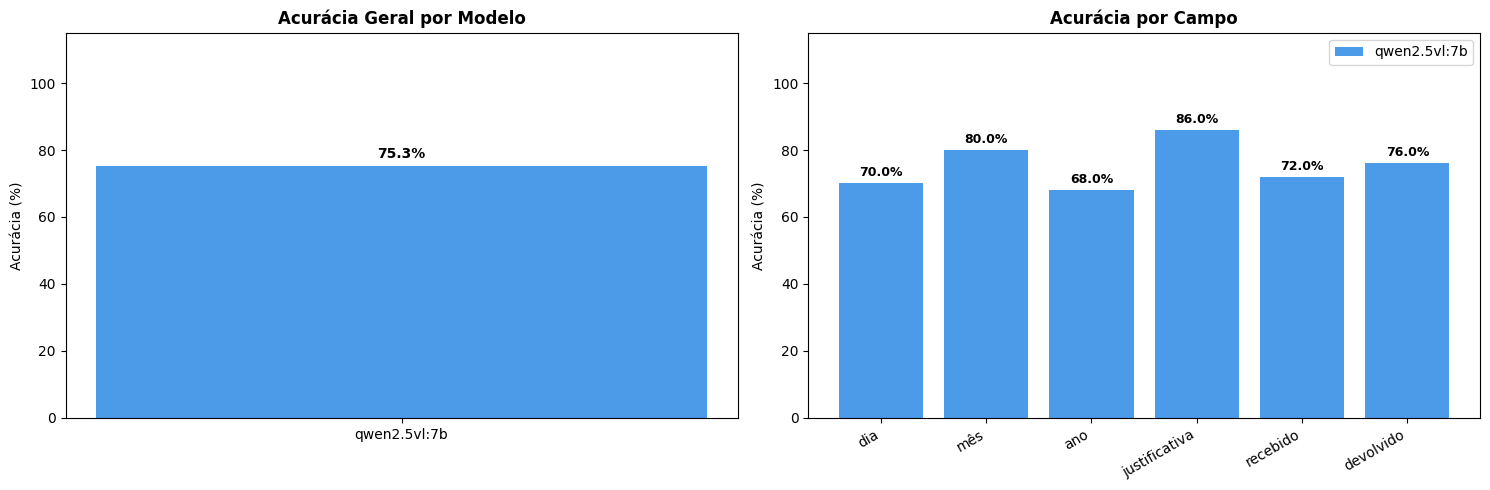

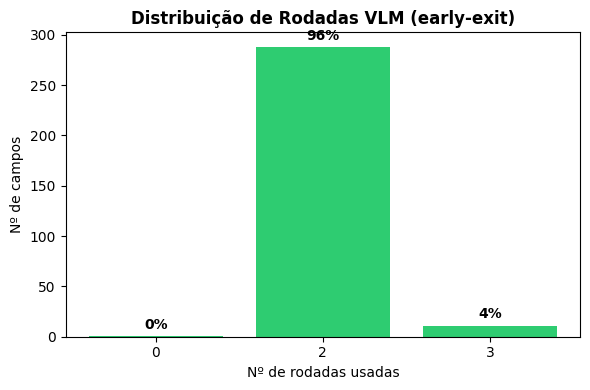

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Pega o modelo definido na célula de configuração (MODELS)
model_to_plot = MODELS[0] if MODELS else None

if model_to_plot:
    # Filtrar o summary para incluir apenas o modelo testado
    summary_filtered = summary[summary["modelo"] == model_to_plot]
    modelos   = summary_filtered["modelo"].tolist()
    acuracias = summary_filtered["acuracia_geral"].tolist()

    # ============================================================
    # GRÁFICO 1 E 2
    # ============================================================

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # ------------------------------------------------------------
    # Gráfico 1: acurácia geral
    # ------------------------------------------------------------

    barras_geral = axes[0].bar(
        modelos,
        acuracias,
        color=["#4C9BE8", "#F06449", "#2ECC71", "#9B59B6"][:len(modelos)]
    )

    axes[0].set_title("Acurácia Geral por Modelo", fontweight="bold")
    axes[0].set_ylabel("Acurácia (%)")
    axes[0].set_ylim(0, 115)

    axes[0].bar_label(
        barras_geral,
        labels=[f"{v:.1f}%" for v in acuracias],
        padding=3,
        fontsize=10,
        fontweight="bold"
    )

    # ------------------------------------------------------------
    # Gráfico 2: acurácia por campo
    # Ordem desejada:
    # dia, mes, ano, justificativa, recebido, devolvido
    # ------------------------------------------------------------

    ordem_campos = [
        "dia",
        "mes",
        "ano",
        "justificativa",
        "total_recebido",
        "total_devolvido"
    ]

    # Mantém apenas os campos que realmente existem no field_acc
    campos = [c for c in ordem_campos if c in field_acc["Campo"].unique()]

    x = np.arange(len(campos))
    width = 0.8 / max(len(modelos), 1)

    colors = ["#4C9BE8", "#F06449", "#2ECC71", "#9B59B6"]

    for i, modelo in enumerate(modelos):
        vals = [
            field_acc[
                (field_acc["Modelo"] == modelo) &
                (field_acc["Campo"] == c)
            ]["Acurácia (%)"].values
            for c in campos
        ]

        vals = [float(v[0]) if len(v) > 0 else 0 for v in vals]

        barras = axes[1].bar(
            x + i * width,
            vals,
            width,
            label=modelo,
            color=colors[i % len(colors)]
        )

        axes[1].bar_label(
            barras,
            labels=[f"{v:.1f}%" for v in vals],
            padding=3,
            fontsize=9,
            fontweight="bold"
        )

    # Nomes mais bonitos no eixo X
    nomes_campos = {
        "dia": "dia",
        "mes": "mês",
        "ano": "ano",
        "justificativa": "justificativa",
        "total_recebido": "recebido",
        "total_devolvido": "devolvido"
    }

    axes[1].set_title("Acurácia por Campo", fontweight="bold")
    axes[1].set_ylabel("Acurácia (%)")
    axes[1].set_xticks(x + width * (len(modelos) - 1) / 2)
    axes[1].set_xticklabels(
        [nomes_campos.get(c, c) for c in campos],
        rotation=30,
        ha="right"
    )
    axes[1].set_ylim(0, 115)
    axes[1].legend()

    fig.tight_layout()
    plt.show()


    # ============================================================
    # GRÁFICO 3: distribuição de rodadas
    # ============================================================

    fig, ax = plt.subplots(figsize=(6, 4))

    # Filtrar df_results para incluir apenas o modelo testado para este gráfico também
    counts = df_results[df_results["modelo"] == model_to_plot]["n_rodadas_usadas"].value_counts().sort_index()

    barras_rodadas = ax.bar(
        counts.index.astype(str),
        counts.values,
        color="#2ECC71"
    )

    ax.set_title("Distribuição de Rodadas VLM (early-exit)", fontweight="bold")
    ax.set_xlabel("Nº de rodadas usadas")
    ax.set_ylabel("Nº de campos")

    filtered_df_for_labels = df_results[df_results['modelo'] == model_to_plot]
    labels_rodadas = [
        f"{(v / len(filtered_df_for_labels) * 100):.0f}%"
        for v in counts.values
    ]

    ax.bar_label(
        barras_rodadas,
        labels=labels_rodadas,
        padding=3,
        fontsize=10,
        fontweight="bold"
    )

    fig.tight_layout()
    plt.show()
else:
    print("Nenhum modelo definido em MODELS para plotar.")

# Q — Exportar resultados

In [27]:
import json, pandas as pd
from pathlib import Path

xlsx_path = OUTPUT_DIR / "benchmark_vlm_resultados.xlsx"
csv_path  = OUTPUT_DIR / "benchmark_vlm_resultados.csv"
json_path = OUTPUT_DIR / "benchmark_vlm_resultados.json"

df_results.to_csv(csv_path, index=False, encoding="utf-8-sig")
df_results.to_json(json_path, orient="records", force_ascii=False, indent=2)

with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    df_results.to_excel(writer, sheet_name="Resultados_Detalhados", index=False)
    field_acc.to_excel(writer, sheet_name="Acuracia_por_Campo", index=False)
    summary.to_excel(writer, sheet_name="Resumo", index=False)
    df_revisao[cols].to_excel(writer, sheet_name="Revisao_Humana", index=False)
    df_dup.to_excel(writer, sheet_name="Duplicados_YOLO", index=False)
    df_validacoes_negocio.to_excel(writer, sheet_name="Validacoes_Demanda_3", index=False)
    df_paginas_validacao.to_excel(writer, sheet_name="Paginas_Validadas", index=False)

print("✅ Exportado:")
print(f"   XLSX : {xlsx_path}")
print(f"   CSV  : {csv_path}")
print(f"   JSON : {json_path}")

✅ Exportado:
   XLSX : /content/drive/MyDrive/colab_yolo/04_07_Qwen_7b/benchmark_vlm_resultados.xlsx
   CSV  : /content/drive/MyDrive/colab_yolo/04_07_Qwen_7b/benchmark_vlm_resultados.csv
   JSON : /content/drive/MyDrive/colab_yolo/04_07_Qwen_7b/benchmark_vlm_resultados.json


# R — Download (Colab)

In [28]:
from google.colab import files

files.download(str(xlsx_path))
files.download(str(csv_path))
files.download(str(json_path))


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
# ============================================================
# RELATÓRIO GERAL — DEMANDA 3
# Pós-processamento e validação de inconsistências
# ============================================================

from pathlib import Path
import pandas as pd
from datetime import datetime

# ------------------------------------------------------------
# 1. Preparação dos caminhos
# ------------------------------------------------------------

RELATORIO_DEMANDA3_DIR = OUTPUT_DIR / "relatorio_demanda_3"
RELATORIO_DEMANDA3_DIR.mkdir(parents=True, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

xlsx_demanda3_path = RELATORIO_DEMANDA3_DIR / f"relatorio_geral_demanda_3_{timestamp}.xlsx"
md_demanda3_path = RELATORIO_DEMANDA3_DIR / f"relatorio_geral_demanda_3_{timestamp}.md"

print("📁 Diretório do relatório:")
print(RELATORIO_DEMANDA3_DIR)


# ------------------------------------------------------------
# 2. Garantia de existência dos DataFrames
# ------------------------------------------------------------

if "df_validacoes_negocio" not in globals():
    raise RuntimeError("df_validacoes_negocio não existe. Rode primeiro a célula M.1 da Demanda 3.")

if "df_paginas_validacao" not in globals():
    raise RuntimeError("df_paginas_validacao não existe. Rode primeiro a célula M.1 da Demanda 3.")

if "df_results" not in globals():
    raise RuntimeError("df_results não existe. Rode primeiro o pipeline principal.")


df_d3_alertas = df_validacoes_negocio.copy()
df_d3_paginas = df_paginas_validacao.copy()
df_d3_resultados = df_results.copy()


# ------------------------------------------------------------
# 3. Métricas gerais da Demanda 3
# ------------------------------------------------------------

total_paginas_avaliadas = (
    df_d3_paginas["pagina"].nunique()
    if "pagina" in df_d3_paginas.columns
    else 0
)

total_modelos_avaliados = (
    df_d3_paginas["modelo"].nunique()
    if "modelo" in df_d3_paginas.columns
    else 0
)

total_alertas = len(df_d3_alertas)

total_paginas_com_alerta = (
    df_d3_alertas["pagina"].nunique()
    if not df_d3_alertas.empty and "pagina" in df_d3_alertas.columns
    else 0
)

percentual_paginas_com_alerta = (
    total_paginas_com_alerta / total_paginas_avaliadas * 100
    if total_paginas_avaliadas > 0
    else 0
)

total_campos_com_alerta = (
    df_d3_alertas[["modelo", "pagina", "campo"]].drop_duplicates().shape[0]
    if not df_d3_alertas.empty and all(c in df_d3_alertas.columns for c in ["modelo", "pagina", "campo"])
    else 0
)

total_campos_marcados_revisao_por_regra = (
    df_d3_resultados[df_d3_resultados.get("regra_negocio_alerta", False).astype(bool)].shape[0]
    if "regra_negocio_alerta" in df_d3_resultados.columns
    else 0
)

total_campos_revisao_geral = (
    df_d3_resultados[df_d3_resultados.get("revisar_humano", False).astype(bool)].shape[0]
    if "revisar_humano" in df_d3_resultados.columns
    else 0
)


df_resumo_executivo = pd.DataFrame([
    {
        "Indicador": "Modelos avaliados",
        "Valor": total_modelos_avaliados,
        "Descrição": "Quantidade de modelos presentes na validação da Demanda 3.",
    },
    {
        "Indicador": "Páginas avaliadas",
        "Valor": total_paginas_avaliadas,
        "Descrição": "Quantidade de páginas que tiveram campos consolidados para validação.",
    },
    {
        "Indicador": "Páginas com alerta de regra de negócio",
        "Valor": total_paginas_com_alerta,
        "Descrição": "Quantidade de páginas em que ao menos uma regra da Demanda 3 foi violada.",
    },
    {
        "Indicador": "% de páginas com alerta",
        "Valor": round(percentual_paginas_com_alerta, 2),
        "Descrição": "Percentual de páginas avaliadas que tiveram inconsistência de regra de negócio.",
    },
    {
        "Indicador": "Total de alertas da Demanda 3",
        "Valor": total_alertas,
        "Descrição": "Quantidade total de inconsistências detectadas pelas regras de negócio.",
    },
    {
        "Indicador": "Campos distintos com alerta",
        "Valor": total_campos_com_alerta,
        "Descrição": "Quantidade de campos distintos impactados por alertas da Demanda 3.",
    },
    {
        "Indicador": "Campos enviados à revisão por regra de negócio",
        "Valor": total_campos_marcados_revisao_por_regra,
        "Descrição": "Campos em df_results com regra_negocio_alerta = True.",
    },
    {
        "Indicador": "Campos enviados à revisão humana geral",
        "Valor": total_campos_revisao_geral,
        "Descrição": "Total geral de campos enviados à revisão, considerando confiança, erro, duplicidade e regra de negócio.",
    },
])


# ------------------------------------------------------------
# 4. Alertas por regra
# ------------------------------------------------------------

if not df_d3_alertas.empty and "regra" in df_d3_alertas.columns:
    df_alertas_por_regra = (
        df_d3_alertas
        .groupby("regra")
        .agg(
            qtd_alertas=("regra", "count"),
            qtd_paginas=("pagina", "nunique"),
            qtd_campos=("campo", "nunique"),
        )
        .reset_index()
        .sort_values("qtd_alertas", ascending=False)
    )

    df_alertas_por_regra["percentual_alertas"] = (
        df_alertas_por_regra["qtd_alertas"] / total_alertas * 100
    ).round(2)

else:
    df_alertas_por_regra = pd.DataFrame(
        columns=["regra", "qtd_alertas", "qtd_paginas", "qtd_campos", "percentual_alertas"]
    )


# ------------------------------------------------------------
# 5. Alertas por campo
# ------------------------------------------------------------

if not df_d3_alertas.empty and "campo" in df_d3_alertas.columns:
    df_alertas_por_campo = (
        df_d3_alertas
        .groupby("campo")
        .agg(
            qtd_alertas=("campo", "count"),
            qtd_paginas=("pagina", "nunique"),
            regras_encontradas=("regra", lambda x: " | ".join(dict.fromkeys(map(str, x)))),
        )
        .reset_index()
        .sort_values("qtd_alertas", ascending=False)
    )

    df_alertas_por_campo["percentual_alertas"] = (
        df_alertas_por_campo["qtd_alertas"] / total_alertas * 100
        if total_alertas > 0
        else 0
    ).round(2)

else:
    df_alertas_por_campo = pd.DataFrame(
        columns=["campo", "qtd_alertas", "qtd_paginas", "regras_encontradas", "percentual_alertas"]
    )


# ------------------------------------------------------------
# 6. Alertas por página
# ------------------------------------------------------------

if not df_d3_alertas.empty and "pagina" in df_d3_alertas.columns:
    df_alertas_por_pagina = (
        df_d3_alertas
        .groupby(["modelo", "pagina"])
        .agg(
            qtd_alertas=("regra", "count"),
            campos_com_alerta=("campo", lambda x: " | ".join(dict.fromkeys(map(str, x)))),
            regras_encontradas=("regra", lambda x: " | ".join(dict.fromkeys(map(str, x)))),
            mensagens=("mensagem", lambda x: " | ".join(dict.fromkeys(map(str, x)))),
            sugestoes=("sugestao", lambda x: " | ".join(
                dict.fromkeys([str(v) for v in x if pd.notna(v) and str(v).strip()])
            )),
        )
        .reset_index()
        .sort_values(["qtd_alertas", "pagina"], ascending=[False, True])
    )

else:
    df_alertas_por_pagina = pd.DataFrame(
        columns=[
            "modelo",
            "pagina",
            "qtd_alertas",
            "campos_com_alerta",
            "regras_encontradas",
            "mensagens",
            "sugestoes",
        ]
    )


# ------------------------------------------------------------
# 7. Campos enviados à revisão por regra de negócio
# ------------------------------------------------------------

if "regra_negocio_alerta" in df_d3_resultados.columns:
    df_revisao_demanda3 = df_d3_resultados[
        df_d3_resultados["regra_negocio_alerta"].astype(bool)
    ].copy()

    cols_revisao_d3 = [
        c for c in [
            "modelo",
            "pagina",
            "campo",
            "extraido_ia",
            "extraido_norm",
            "gabarito",
            "status",
            "score_confiabilidade",
            "limiar_revisao",
            "revisar_humano",
            "acao",
            "qtd_alertas_regra_negocio",
            "regra_negocio_regras",
            "regra_negocio_mensagem",
            "sugestao_validacao",
            "crop_path",
        ]
        if c in df_revisao_demanda3.columns
    ]

    df_revisao_demanda3 = df_revisao_demanda3[cols_revisao_d3].sort_values(
        [c for c in ["modelo", "pagina", "campo"] if c in cols_revisao_d3]
    )

else:
    df_revisao_demanda3 = pd.DataFrame()


# ------------------------------------------------------------
# 8. Campos que foram para revisão geral, mas NÃO pela Demanda 3
# ------------------------------------------------------------

if "revisar_humano" in df_d3_resultados.columns and "regra_negocio_alerta" in df_d3_resultados.columns:
    df_revisao_sem_demanda3 = df_d3_resultados[
        df_d3_resultados["revisar_humano"].astype(bool)
        & ~df_d3_resultados["regra_negocio_alerta"].astype(bool)
    ].copy()

    cols_sem_d3 = [
        c for c in [
            "modelo",
            "pagina",
            "campo",
            "extraido_ia",
            "extraido_norm",
            "gabarito",
            "status",
            "score_confiabilidade",
            "limiar_revisao",
            "alerta_duplicado",
            "revisar_humano",
            "acao",
            "crop_path",
        ]
        if c in df_revisao_sem_demanda3.columns
    ]

    df_revisao_sem_demanda3 = df_revisao_sem_demanda3[cols_sem_d3].sort_values(
        [c for c in ["modelo", "pagina", "campo"] if c in cols_sem_d3]
    )

else:
    df_revisao_sem_demanda3 = pd.DataFrame()


# ------------------------------------------------------------
# 9. Classificação textual das regras
# ------------------------------------------------------------

mapa_descricao_regras = {
    "SOMA_INCOMPATIVEL_COM_TOTAL": "A soma entre Total Recebido e Total Devolvido não fecha com o total esperado da guia.",
    "QUANTIDADE_AUSENTE": "O campo de quantidade está ausente, vazio ou não pôde ser interpretado como número.",
    "QUANTIDADE_FORA_DA_FAIXA": "A quantidade extraída está fora da faixa plausível em relação ao total esperado.",
    "DATA_COMPONENTE_AUSENTE": "Algum componente da data, como dia, mês ou ano, está ausente ou não numérico.",
    "DIA_FORA_DA_FAIXA": "O dia extraído está fora da faixa permitida de 1 a 31.",
    "MES_FORA_DA_FAIXA": "O mês extraído está fora da faixa permitida de 1 a 12.",
    "ANO_FORA_DA_FAIXA": "O ano extraído está fora da faixa configurada como válida.",
    "ANO_DIFERENTE_DO_ESPERADO": "O ano extraído é diferente do ano esperado configurado.",
    "DIA_INVALIDO_PARA_MES": "O dia não existe para o mês e ano informados, como 31/02 ou 29/02 em ano não bissexto.",
}

if not df_alertas_por_regra.empty:
    df_alertas_por_regra["descricao_regra"] = df_alertas_por_regra["regra"].map(
        mapa_descricao_regras
    ).fillna("Regra sem descrição cadastrada.")
else:
    df_alertas_por_regra["descricao_regra"] = []


# ------------------------------------------------------------
# 10. Geração do relatório Markdown
# ------------------------------------------------------------

def tabela_markdown_segura(df, max_linhas=30):
    if df is None or df.empty:
        return "_Sem registros._"

    df_show = df.head(max_linhas).copy()

    try:
        return df_show.to_markdown(index=False)
    except Exception:
        return df_show.to_string(index=False)


linhas_md = []

linhas_md.append("# Relatório Geral — Demanda 3")
linhas_md.append("")
linhas_md.append("## 1. Objetivo")
linhas_md.append("")
linhas_md.append(
    "Este relatório consolida apenas os resultados da etapa de pós-processamento "
    "e validação de regra de negócio implementada para a Demanda 3."
)
linhas_md.append("")
linhas_md.append(
    "A Demanda 3 tem como objetivo identificar inconsistências nos dados extraídos, "
    "principalmente em campos de quantidade e data, direcionando a revisão humana "
    "para páginas e campos com maior probabilidade de erro."
)
linhas_md.append("")

linhas_md.append("## 2. Resumo executivo")
linhas_md.append("")
linhas_md.append(tabela_markdown_segura(df_resumo_executivo, max_linhas=50))
linhas_md.append("")

linhas_md.append("## 3. Alertas por regra")
linhas_md.append("")
linhas_md.append(tabela_markdown_segura(df_alertas_por_regra, max_linhas=50))
linhas_md.append("")

linhas_md.append("## 4. Alertas por campo")
linhas_md.append("")
linhas_md.append(tabela_markdown_segura(df_alertas_por_campo, max_linhas=50))
linhas_md.append("")

linhas_md.append("## 5. Páginas com mais alertas")
linhas_md.append("")
linhas_md.append(tabela_markdown_segura(df_alertas_por_pagina, max_linhas=50))
linhas_md.append("")

linhas_md.append("## 6. Interpretação")
linhas_md.append("")
linhas_md.append(
    "A coluna `qtd_alertas_regra_negocio` representa somente alertas gerados pelas regras da Demanda 3. "
    "Ela não representa todos os motivos possíveis de revisão humana."
)
linhas_md.append("")
linhas_md.append(
    "Um campo pode estar em `REVISAR HUMANO` mesmo sem alerta da Demanda 3, por exemplo por baixa confiança "
    "do modelo, erro de inferência, valor vazio ou duplicidade de detecção."
)
linhas_md.append("")
linhas_md.append(
    "Por outro lado, quando `regra_negocio_alerta = True`, significa que o campo foi sinalizado especificamente "
    "por inconsistência de regra de negócio."
)
linhas_md.append("")

linhas_md.append("## 7. Relação com acurácia")
linhas_md.append("")
linhas_md.append(
    "As validações da Demanda 3 não corrigem automaticamente os valores extraídos e não transformam erros em acertos "
    "no gráfico de acurácia bruta."
)
linhas_md.append("")
linhas_md.append(
    "A acurácia continua medindo o desempenho do VLM contra o gabarito. "
    "A Demanda 3 mede a consistência dos dados extraídos e ajuda a priorizar revisão humana."
)
linhas_md.append("")

linhas_md.append("## 8. Campos enviados à revisão por regra de negócio")
linhas_md.append("")
linhas_md.append(tabela_markdown_segura(df_revisao_demanda3, max_linhas=50))
linhas_md.append("")

linhas_md.append("## 9. Observação final")
linhas_md.append("")
linhas_md.append(
    "Este relatório deve ser usado como uma visão específica da Demanda 3, separada do benchmark geral de extração. "
    "Ele mostra onde as regras de consistência detectaram problemas, quais campos foram afetados e quais sugestões "
    "podem apoiar a revisão humana."
)
linhas_md.append("")

md_demanda3_path.write_text("\n".join(linhas_md), encoding="utf-8")


# ------------------------------------------------------------
# 11. Exportação Excel
# ------------------------------------------------------------

with pd.ExcelWriter(xlsx_demanda3_path, engine="openpyxl") as writer:
    df_resumo_executivo.to_excel(writer, sheet_name="Resumo_Executivo", index=False)
    df_alertas_por_regra.to_excel(writer, sheet_name="Alertas_por_Regra", index=False)
    df_alertas_por_campo.to_excel(writer, sheet_name="Alertas_por_Campo", index=False)
    df_alertas_por_pagina.to_excel(writer, sheet_name="Alertas_por_Pagina", index=False)
    df_revisao_demanda3.to_excel(writer, sheet_name="Revisao_Demanda_3", index=False)
    df_revisao_sem_demanda3.to_excel(writer, sheet_name="Revisao_Sem_Demanda_3", index=False)
    df_d3_alertas.to_excel(writer, sheet_name="Validacoes_Detalhadas", index=False)
    df_d3_paginas.to_excel(writer, sheet_name="Paginas_Validadas", index=False)


# ------------------------------------------------------------
# 12. Exibição no notebook
# ------------------------------------------------------------

print("\n✅ Relatório geral da Demanda 3 gerado com sucesso!")
print(f"📄 Markdown: {md_demanda3_path}")
print(f"📊 Excel:    {xlsx_demanda3_path}")

print("\n📌 Resumo executivo:")
display(df_resumo_executivo)

print("\n📌 Alertas por regra:")
display(df_alertas_por_regra)

print("\n📌 Alertas por campo:")
display(df_alertas_por_campo)

print("\n📌 Páginas com mais alertas:")
display(df_alertas_por_pagina.head(20))

print("\n📌 Campos enviados à revisão especificamente pela Demanda 3:")
display(df_revisao_demanda3.head(30))

📁 Diretório do relatório:
/content/drive/MyDrive/colab_yolo/04_07_Qwen_7b/relatorio_demanda_3

✅ Relatório geral da Demanda 3 gerado com sucesso!
📄 Markdown: /content/drive/MyDrive/colab_yolo/04_07_Qwen_7b/relatorio_demanda_3/relatorio_geral_demanda_3_20260705_022129.md
📊 Excel:    /content/drive/MyDrive/colab_yolo/04_07_Qwen_7b/relatorio_demanda_3/relatorio_geral_demanda_3_20260705_022129.xlsx

📌 Resumo executivo:


,Indicador,Valor,Descrição
0,Modelos avaliados,1.0,Quantidade de modelos presentes na validação d...
1,Páginas avaliadas,50.0,Quantidade de páginas que tiveram campos conso...
2,Páginas com alerta de regra de negócio,39.0,Quantidade de páginas em que ao menos uma regr...
3,% de páginas com alerta,78.0,Percentual de páginas avaliadas que tiveram in...
4,Total de alertas da Demanda 3,95.0,Quantidade total de inconsistências detectadas...
5,Campos distintos com alerta,86.0,Quantidade de campos distintos impactados por ...
6,Campos enviados à revisão por regra de negócio,86.0,Campos em df_results com regra_negocio_alerta ...
7,Campos enviados à revisão humana geral,89.0,"Total geral de campos enviados à revisão, cons..."



📌 Alertas por regra:


,regra,qtd_alertas,qtd_paginas,qtd_campos,percentual_alertas,descricao_regra
8,SOMA_INCOMPATIVEL_COM_TOTAL,38,19,2,40.00,A soma entre Total Recebido e Total Devolvido ...
0,ANO_FORA_DA_FAIXA,30,30,1,31.58,O ano extraído está fora da faixa configurada ...
7,QUANTIDADE_FORA_DA_FAIXA,7,7,2,7.37,A quantidade extraída está fora da faixa plaus...
4,JUSTIFICATIVA_AUSENTE,6,6,1,6.32,Regra sem descrição cadastrada.
5,JUSTIFICATIVA_INVALIDA,5,5,1,5.26,Regra sem descrição cadastrada.
3,DIA_INVALIDO_PARA_MES,4,4,1,4.21,"O dia não existe para o mês e ano informados, ..."
2,DIA_FORA_DA_FAIXA,2,2,1,2.11,O dia extraído está fora da faixa permitida de...
1,DATA_COMPONENTE_AUSENTE,2,2,1,2.11,"Algum componente da data, como dia, mês ou ano..."
6,MES_FORA_DA_FAIXA,1,1,1,1.05,O mês extraído está fora da faixa permitida de...



📌 Alertas por campo:


,campo,qtd_alertas,qtd_paginas,regras_encontradas,percentual_alertas
0,ano,30,30,ANO_FORA_DA_FAIXA,31.58
5,total_recebido,24,19,SOMA_INCOMPATIVEL_COM_TOTAL | QUANTIDADE_FORA_...,25.26
4,total_devolvido,21,19,SOMA_INCOMPATIVEL_COM_TOTAL | QUANTIDADE_FORA_...,22.11
2,justificativa,11,11,JUSTIFICATIVA_INVALIDA | JUSTIFICATIVA_AUSENTE,11.58
1,dia,8,6,DATA_COMPONENTE_AUSENTE | DIA_FORA_DA_FAIXA | ...,8.42
3,mes,1,1,MES_FORA_DA_FAIXA,1.05



📌 Páginas com mais alertas:


,modelo,pagina,qtd_alertas,campos_com_alerta,regras_encontradas,mensagens,sugestoes
16,qwen2.5vl:7b,22,6,total_devolvido | total_recebido | justificati...,QUANTIDADE_FORA_DA_FAIXA | SOMA_INCOMPATIVEL_C...,Total Devolvido 497.6 está fora da faixa esper...,Total Devolvido possível: 495.504KG | 28/02/2019
23,qwen2.5vl:7b,33,6,total_recebido | total_devolvido | justificati...,SOMA_INCOMPATIVEL_COM_TOTAL | JUSTIFICATIVA_IN...,Soma incompatível: recebido 100 + devolvido 16...,Total Recebido possível: 328.1KG | Total Devol...
18,qwen2.5vl:7b,27,5,total_recebido | total_devolvido | justificati...,QUANTIDADE_FORA_DA_FAIXA | SOMA_INCOMPATIVEL_C...,Total Recebido 500 está fora da faixa esperada...,Total Recebido possível: 496KG
36,qwen2.5vl:7b,48,5,total_recebido | total_devolvido | mes | ano,QUANTIDADE_FORA_DA_FAIXA | SOMA_INCOMPATIVEL_C...,Total Recebido 500 está fora da faixa esperada...,Total Recebido possível: 495.996KG
19,qwen2.5vl:7b,28,4,total_recebido | total_devolvido | ano,QUANTIDADE_FORA_DA_FAIXA | SOMA_INCOMPATIVEL_C...,Total Recebido 500 está fora da faixa esperada...,Total Recebido possível: 495.997KG
24,qwen2.5vl:7b,36,4,total_recebido | total_devolvido | ano,QUANTIDADE_FORA_DA_FAIXA | SOMA_INCOMPATIVEL_C...,Total Recebido 4000 está fora da faixa esperad...,Total Recebido possível: 495.95KG
29,qwen2.5vl:7b,41,4,total_recebido | total_devolvido | ano,QUANTIDADE_FORA_DA_FAIXA | SOMA_INCOMPATIVEL_C...,Total Recebido 500 está fora da faixa esperada...,Total Recebido possível: 495.998KG
30,qwen2.5vl:7b,42,4,total_recebido | total_devolvido | ano | dia,SOMA_INCOMPATIVEL_COM_TOTAL | ANO_FORA_DA_FAIX...,Soma incompatível: recebido 30 + devolvido 192...,Total Recebido possível: 304KG | Total Devolvi...
35,qwen2.5vl:7b,47,4,total_recebido | total_devolvido | justificati...,SOMA_INCOMPATIVEL_COM_TOTAL | JUSTIFICATIVA_IN...,Soma incompatível: recebido 353.9 + devolvido ...,Total Recebido possível: 456KG | Total Devolvi...
4,qwen2.5vl:7b,7,3,dia | ano,DIA_FORA_DA_FAIXA | ANO_FORA_DA_FAIXA | DIA_IN...,Dia 47 fora da faixa permitida 1–31. | Ano 202...,30/06/2020



📌 Campos enviados à revisão especificamente pela Demanda 3:


,modelo,pagina,campo,extraido_ia,gabarito,status,score_confiabilidade,limiar_revisao,revisar_humano,acao,qtd_alertas_regra_negocio,regra_negocio_regras,regra_negocio_mensagem,sugestao_validacao,crop_path
0,qwen2.5vl:7b,1,ano,"ERRO: HTTPConnectionPool(host='127.0.0.1', por...",2026,❌,0.0,85.0,True,REVISAR HUMANO,1,ANO_FORA_DA_FAIXA,Ano 12700111434120 fora da faixa permitida 202...,,/content/drive/MyDrive/colab_yolo/04_07_Qwen_7...
12,qwen2.5vl:7b,3,ano,2083,2013,❌,60.0,85.0,True,REVISAR HUMANO,1,ANO_FORA_DA_FAIXA,Ano 2083 fora da faixa permitida 2025–2026.,,/content/drive/MyDrive/colab_yolo/04_07_Qwen_7...
14,qwen2.5vl:7b,3,justificativa,7,7,✅,80.0,90.0,True,REVISAR HUMANO,1,JUSTIFICATIVA_INVALIDA,Justificativa 7 fora da faixa permitida (1 a 5).,,/content/drive/MyDrive/colab_yolo/04_07_Qwen_7...
24,qwen2.5vl:7b,5,ano,2019,VAZIO,❌,60.0,85.0,True,REVISAR HUMANO,1,ANO_FORA_DA_FAIXA,Ano 2019 fora da faixa permitida 2025–2026.,,/content/drive/MyDrive/colab_yolo/04_07_Qwen_7...
25,qwen2.5vl:7b,5,dia,VAZIO,VAZIO,✅,100.0,80.0,True,REVISAR HUMANO,1,DATA_COMPONENTE_AUSENTE,Dia ausente ou não numérico.,,/content/drive/MyDrive/colab_yolo/04_07_Qwen_7...
32,qwen2.5vl:7b,6,justificativa,41,1,❌,80.0,90.0,True,REVISAR HUMANO,1,JUSTIFICATIVA_INVALIDA,Justificativa 41 fora da faixa permitida (1 a 5).,,/content/drive/MyDrive/colab_yolo/04_07_Qwen_7...
36,qwen2.5vl:7b,7,ano,2020,2020,✅,60.0,85.0,True,REVISAR HUMANO,1,ANO_FORA_DA_FAIXA,Ano 2020 fora da faixa permitida 2025–2026.,,/content/drive/MyDrive/colab_yolo/04_07_Qwen_7...
37,qwen2.5vl:7b,7,dia,47,17,❌,60.0,80.0,True,REVISAR HUMANO,2,DIA_FORA_DA_FAIXA | DIA_INVALIDO_PARA_MES,Dia 47 fora da faixa permitida 1–31. | Dia 47 ...,30/06/2020,/content/drive/MyDrive/colab_yolo/04_07_Qwen_7...
43,qwen2.5vl:7b,8,dia,VAZIO,VAZIO,✅,100.0,80.0,True,REVISAR HUMANO,1,DATA_COMPONENTE_AUSENTE,Dia ausente ou não numérico.,,/content/drive/MyDrive/colab_yolo/04_07_Qwen_7...
54,qwen2.5vl:7b,10,ano,2023,2023,✅,60.0,85.0,True,REVISAR HUMANO,1,ANO_FORA_DA_FAIXA,Ano 2023 fora da faixa permitida 2025–2026.,,/content/drive/MyDrive/colab_yolo/04_07_Qwen_7...


In [30]:
# ============================================================
# RELATÓRIO PDF PREMIUM CORRIGIDO — DEMANDA 3
# Compatível com múltiplos modelos + gráficos sem deformação
# ============================================================
!pip install reportlab
from pathlib import Path
from datetime import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import textwrap

try:
    from PIL import Image as PILImage
except Exception:
    PILImage = None

try:
    from reportlab.lib import colors
    from reportlab.lib.pagesizes import A4
    from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
    from reportlab.lib.enums import TA_CENTER
    from reportlab.lib.units import cm
    from reportlab.platypus import (
        SimpleDocTemplate,
        Paragraph,
        Spacer,
        Table,
        TableStyle,
        PageBreak,
        Image,
    )
except Exception as e:
    raise ImportError(
        "A biblioteca reportlab não está instalada. "
        "No Colab, rode: !pip install reportlab"
    ) from e


# ============================================================
# 1. Validações iniciais
# ============================================================

if "df_results" not in globals():
    raise RuntimeError("df_results não existe. Rode primeiro o pipeline principal.")

if "df_validacoes_negocio" not in globals():
    raise RuntimeError("df_validacoes_negocio não existe. Rode primeiro a célula M.1 da Demanda 3.")

if "df_paginas_validacao" not in globals():
    raise RuntimeError("df_paginas_validacao não existe. Rode primeiro a célula M.1 da Demanda 3.")


df_d3_alertas = df_validacoes_negocio.copy()
df_d3_paginas = df_paginas_validacao.copy()
df_d3_resultados = df_results.copy()


# ============================================================
# 2. Diretórios
# ============================================================

RELATORIO_DEMANDA3_DIR = OUTPUT_DIR / "relatorio_demanda_3"
RELATORIO_DEMANDA3_DIR.mkdir(parents=True, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

pdf_path = RELATORIO_DEMANDA3_DIR / f"relatorio_premium_demanda_3_corrigido_{timestamp}.pdf"
xlsx_path = RELATORIO_DEMANDA3_DIR / f"dados_relatorio_premium_demanda_3_corrigido_{timestamp}.xlsx"

charts_dir = RELATORIO_DEMANDA3_DIR / f"graficos_premium_corrigido_{timestamp}"
charts_dir.mkdir(parents=True, exist_ok=True)


# ============================================================
# 3. Tema visual
# ============================================================

THEME = {
    "azul_escuro": "#17365D",
    "azul": "#1F4E79",
    "azul_medio": "#2F75B5",
    "azul_claro": "#D9EAF7",
    "cinza_texto": "#333333",
    "cinza_medio": "#666666",
    "cinza_claro": "#F4F7FB",
    "cinza_borda": "#D9E2F3",
    "verde": "#70AD47",
    "laranja": "#ED7D31",
    "vermelho": "#C00000",
    "amarelo": "#FFC000",
}


# ============================================================
# 4. Funções auxiliares
# ============================================================

def safe_len(df):
    return 0 if df is None else int(len(df))


def safe_nunique(df, col):
    if df is None or df.empty or col not in df.columns:
        return 0
    return int(df[col].nunique())


def bool_col(df, col):
    if col not in df.columns:
        return pd.Series([False] * len(df), index=df.index)
    return df[col].fillna(False).astype(bool)


def fmt_int(x):
    try:
        return f"{int(x):,}".replace(",", ".")
    except Exception:
        return str(x)


def fmt_pct(x):
    try:
        return f"{float(x):.1f}%".replace(".", ",")
    except Exception:
        return str(x)


def limpar_texto(x, max_chars=420):
    if pd.isna(x):
        return ""
    s = str(x).replace("\n", " ").replace("\r", " ")
    s = " ".join(s.split())
    if len(s) > max_chars:
        return s[:max_chars - 3] + "..."
    return s


def wrap_label(label, width=30):
    return "\n".join(textwrap.wrap(str(label), width=width))


def rl_image_preserve(path, max_width, max_height):
    """
    Insere imagem no PDF preservando proporção.
    Corrige o problema de gráficos esticados/deformados.
    """
    path = str(path)

    if PILImage is None:
        return Image(path, width=max_width, height=max_height)

    with PILImage.open(path) as img:
        w_px, h_px = img.size

    aspect = w_px / h_px

    width = max_width
    height = width / aspect

    if height > max_height:
        height = max_height
        width = height * aspect

    return Image(path, width=width, height=height)


def gerar_barh_com_valores(
    df,
    label_col,
    value_col,
    title,
    subtitle,
    out_path,
    top_n=12,
    bar_color=None,
):
    if df is None or df.empty or label_col not in df.columns or value_col not in df.columns:
        return None

    data = df[[label_col, value_col]].copy()
    data = data.sort_values(value_col, ascending=False).head(top_n)

    if data.empty:
        return None

    data[label_col] = data[label_col].astype(str).apply(lambda x: wrap_label(x, 34))
    data = data.sort_values(value_col, ascending=True)

    max_val = data[value_col].max()
    x_lim = max_val * 1.25 if max_val > 0 else 1

    fig, ax = plt.subplots(figsize=(11.5, 6.6))

    cor = bar_color or THEME["azul_medio"]
    bars = ax.barh(data[label_col], data[value_col], color=cor, edgecolor="none")

    ax.set_xlim(0, x_lim)
    ax.set_title(title, fontsize=16, fontweight="bold", color=THEME["azul_escuro"], pad=22)

    if subtitle:
        ax.text(
            0,
            1.035,
            subtitle,
            transform=ax.transAxes,
            fontsize=9,
            color=THEME["cinza_medio"],
            va="bottom",
        )

    ax.set_xlabel("Quantidade", fontsize=9, color=THEME["cinza_texto"])
    ax.tick_params(axis="y", labelsize=8)
    ax.tick_params(axis="x", labelsize=8)

    ax.grid(axis="x", linestyle="--", alpha=0.25)
    ax.set_axisbelow(True)

    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)

    ax.spines["bottom"].set_color("#CCCCCC")

    for bar in bars:
        width = bar.get_width()
        y = bar.get_y() + bar.get_height() / 2
        ax.text(
            width + (x_lim * 0.018),
            y,
            fmt_int(width),
            va="center",
            ha="left",
            fontsize=9.5,
            fontweight="bold",
            color=THEME["azul_escuro"],
        )

    fig.tight_layout()
    fig.savefig(out_path, dpi=220, bbox_inches="tight", facecolor="white")
    plt.close(fig)

    return out_path


def gerar_donut(
    labels,
    values,
    title,
    subtitle,
    out_path,
    colors_list=None,
):
    total = sum(values)

    if total == 0:
        return None

    colors_list = colors_list or [THEME["laranja"], THEME["cinza_borda"]]

    fig, ax = plt.subplots(figsize=(8.6, 6.2))

    wedges, _ = ax.pie(
        values,
        labels=None,
        startangle=90,
        counterclock=False,
        colors=colors_list,
        wedgeprops=dict(width=0.38, edgecolor="white"),
    )

    ax.text(
        0,
        0.07,
        fmt_int(total),
        ha="center",
        va="center",
        fontsize=24,
        fontweight="bold",
        color=THEME["azul_escuro"],
    )
    ax.text(
        0,
        -0.15,
        "páginas avaliadas",
        ha="center",
        va="center",
        fontsize=9,
        color=THEME["cinza_medio"],
    )

    legend_labels = []
    for label, value in zip(labels, values):
        pct = value / total * 100 if total else 0
        legend_labels.append(f"{label}: {fmt_int(value)} ({fmt_pct(pct)})")

    ax.legend(
        wedges,
        legend_labels,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        fontsize=9,
        frameon=False,
    )

    ax.set_title(title, fontsize=16, fontweight="bold", color=THEME["azul_escuro"], pad=20)

    if subtitle:
        fig.text(
            0.08,
            0.91,
            subtitle,
            fontsize=9,
            color=THEME["cinza_medio"],
        )

    ax.axis("equal")
    fig.tight_layout()
    fig.savefig(out_path, dpi=220, bbox_inches="tight", facecolor="white")
    plt.close(fig)

    return out_path


def gerar_barras_empilhadas_revisao(qtd_d3, qtd_outros, out_path):
    total = qtd_d3 + qtd_outros

    if total == 0:
        return None

    fig, ax = plt.subplots(figsize=(10.8, 4.4))

    ax.barh(
        ["Campos em revisão"],
        [qtd_d3],
        color=THEME["azul_medio"],
        label="Demanda 3",
    )
    ax.barh(
        ["Campos em revisão"],
        [qtd_outros],
        left=[qtd_d3],
        color=THEME["cinza_borda"],
        label="Outros motivos",
    )

    ax.set_xlim(0, total * 1.18)

    if qtd_d3 > 0:
        ax.text(
            qtd_d3 / 2,
            0,
            fmt_int(qtd_d3),
            ha="center",
            va="center",
            color="white",
            fontweight="bold",
            fontsize=11,
        )

    if qtd_outros > 0:
        ax.text(
            qtd_d3 + qtd_outros / 2,
            0,
            fmt_int(qtd_outros),
            ha="center",
            va="center",
            color=THEME["azul_escuro"],
            fontweight="bold",
            fontsize=11,
        )

    ax.text(
        total + total * 0.025,
        0,
        f"Total: {fmt_int(total)}",
        va="center",
        ha="left",
        fontsize=10.5,
        fontweight="bold",
        color=THEME["azul_escuro"],
    )

    ax.set_title(
        "Composição da fila de revisão humana",
        fontsize=15,
        fontweight="bold",
        color=THEME["azul_escuro"],
        pad=22,
    )

    ax.text(
        0,
        1.07,
        "Campos enviados à revisão por alerta da Demanda 3 versus outros critérios.",
        transform=ax.transAxes,
        fontsize=9,
        color=THEME["cinza_medio"],
        va="bottom",
    )

    ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.42), ncol=2, frameon=False, fontsize=9)

    ax.set_yticks([])
    ax.set_xlabel("Quantidade de campos", fontsize=9)
    ax.grid(axis="x", linestyle="--", alpha=0.22)

    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)

    ax.spines["bottom"].set_color("#CCCCCC")

    fig.tight_layout()
    fig.savefig(out_path, dpi=220, bbox_inches="tight", facecolor="white")
    plt.close(fig)

    return out_path


def tabela_pdf(df, colunas, larguras, max_linhas=15, font_size=7, header_bg=None):
    if df is None or df.empty:
        return Paragraph("Sem registros.", styles["Body"])

    cols = [c for c in colunas if c in df.columns]

    if not cols:
        return Paragraph("Sem colunas disponíveis para exibição.", styles["Body"])

    df_show = df[cols].head(max_linhas).copy()

    data = [[Paragraph(str(c), styles["TableHeader"]) for c in cols]]

    for _, row in df_show.iterrows():
        linha = []
        for c in cols:
            linha.append(Paragraph(limpar_texto(row[c], max_chars=220), styles["TableCell"]))
        data.append(linha)

    table = Table(data, colWidths=larguras[:len(cols)], repeatRows=1)

    table.setStyle(TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), colors.HexColor(header_bg or THEME["azul"])),
        ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
        ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
        ("ALIGN", (0, 0), (-1, 0), "CENTER"),
        ("VALIGN", (0, 0), (-1, -1), "TOP"),
        ("FONTNAME", (0, 1), (-1, -1), "Helvetica"),
        ("FONTSIZE", (0, 0), (-1, -1), font_size),
        ("GRID", (0, 0), (-1, -1), 0.25, colors.HexColor(THEME["cinza_borda"])),
        ("ROWBACKGROUNDS", (0, 1), (-1, -1), [colors.white, colors.HexColor(THEME["cinza_claro"])]),
        ("LEFTPADDING", (0, 0), (-1, -1), 4),
        ("RIGHTPADDING", (0, 0), (-1, -1), 4),
        ("TOPPADDING", (0, 0), (-1, -1), 4),
        ("BOTTOMPADDING", (0, 0), (-1, -1), 4),
    ]))

    return table


def on_page(canvas, doc):
    canvas.saveState()

    page_width, page_height = A4

    canvas.setFillColor(colors.HexColor(THEME["azul_escuro"]))
    canvas.rect(0, page_height - 1.25 * cm, page_width, 1.25 * cm, fill=True, stroke=False)

    canvas.setFillColor(colors.white)
    canvas.setFont("Helvetica-Bold", 9)
    canvas.drawString(1.35 * cm, page_height - 0.78 * cm, "Relatório Premium - Demanda 3")

    canvas.setFont("Helvetica", 8)
    canvas.drawRightString(
        page_width - 1.35 * cm,
        page_height - 0.78 * cm,
        datetime.now().strftime("%d/%m/%Y %H:%M"),
    )

    canvas.setFillColor(colors.HexColor("#888888"))
    canvas.setFont("Helvetica", 8)
    canvas.drawCentredString(page_width / 2, 0.75 * cm, f"Página {doc.page}")

    canvas.restoreState()


# ============================================================
# 5. Métricas gerais
# ============================================================

total_paginas_avaliadas = safe_nunique(df_d3_paginas, "pagina")
total_modelos_avaliados = safe_nunique(df_d3_paginas, "modelo")
total_alertas = safe_len(df_d3_alertas)
total_paginas_com_alerta = safe_nunique(df_d3_alertas, "pagina")
total_paginas_sem_alerta = max(total_paginas_avaliadas - total_paginas_com_alerta, 0)

pct_paginas_com_alerta = (
    total_paginas_com_alerta / total_paginas_avaliadas * 100
    if total_paginas_avaliadas > 0
    else 0
)

if not df_d3_alertas.empty and all(c in df_d3_alertas.columns for c in ["modelo", "pagina", "campo"]):
    total_campos_distintos_com_alerta = (
        df_d3_alertas[["modelo", "pagina", "campo"]]
        .drop_duplicates()
        .shape[0]
    )
else:
    total_campos_distintos_com_alerta = 0

campos_revisao_demanda3 = int(bool_col(df_d3_resultados, "regra_negocio_alerta").sum())
campos_revisao_geral = int(bool_col(df_d3_resultados, "revisar_humano").sum())
campos_revisao_outros_motivos = max(campos_revisao_geral - campos_revisao_demanda3, 0)

participacao_d3_na_revisao = (
    campos_revisao_demanda3 / campos_revisao_geral * 100
    if campos_revisao_geral > 0
    else 0
)


# ============================================================
# 6. Métricas por modelo
# ============================================================

if "modelo" in df_d3_resultados.columns:
    modelos = sorted(df_d3_resultados["modelo"].dropna().unique())
else:
    modelos = ["modelo_unico"]

linhas_modelo = []

for modelo in modelos:
    if "modelo" in df_d3_resultados.columns:
        res_m = df_d3_resultados[df_d3_resultados["modelo"] == modelo].copy()
    else:
        res_m = df_d3_resultados.copy()

    if "modelo" in df_d3_alertas.columns:
        alertas_m = df_d3_alertas[df_d3_alertas["modelo"] == modelo].copy()
    else:
        alertas_m = df_d3_alertas.copy()

    if "modelo" in df_d3_paginas.columns:
        paginas_m = df_d3_paginas[df_d3_paginas["modelo"] == modelo].copy()
    else:
        paginas_m = df_d3_paginas.copy()

    pag_avaliadas_m = safe_nunique(paginas_m, "pagina")
    pag_alerta_m = safe_nunique(alertas_m, "pagina")
    total_alertas_m = len(alertas_m)
    campos_revisao_d3_m = int(bool_col(res_m, "regra_negocio_alerta").sum())
    campos_revisao_geral_m = int(bool_col(res_m, "revisar_humano").sum())

    pct_pag_alerta_m = (
        pag_alerta_m / pag_avaliadas_m * 100
        if pag_avaliadas_m > 0
        else 0
    )

    linhas_modelo.append({
        "modelo": modelo,
        "paginas_avaliadas": pag_avaliadas_m,
        "paginas_com_alerta": pag_alerta_m,
        "pct_paginas_com_alerta": round(pct_pag_alerta_m, 2),
        "total_alertas_d3": total_alertas_m,
        "campos_revisao_d3": campos_revisao_d3_m,
        "campos_revisao_geral": campos_revisao_geral_m,
    })

df_resumo_por_modelo = pd.DataFrame(linhas_modelo)

if not df_resumo_por_modelo.empty:
    df_resumo_por_modelo = df_resumo_por_modelo.sort_values("total_alertas_d3", ascending=False)


# ============================================================
# 7. Tabelas analíticas
# ============================================================

df_resumo_executivo = pd.DataFrame([
    {
        "Indicador": "Modelos avaliados",
        "Valor": total_modelos_avaliados,
        "Interpretação": "Quantidade de modelos presentes na validação.",
    },
    {
        "Indicador": "Páginas avaliadas",
        "Valor": total_paginas_avaliadas,
        "Interpretação": "Páginas com campos consolidados para validação.",
    },
    {
        "Indicador": "Páginas com alerta",
        "Valor": total_paginas_com_alerta,
        "Interpretação": "Páginas que violaram ao menos uma regra da Demanda 3.",
    },
    {
        "Indicador": "% páginas com alerta",
        "Valor": round(pct_paginas_com_alerta, 2),
        "Interpretação": "Percentual de páginas avaliadas com inconsistência.",
    },
    {
        "Indicador": "Total de alertas",
        "Valor": total_alertas,
        "Interpretação": "Quantidade total de inconsistências detectadas.",
    },
    {
        "Indicador": "Campos distintos com alerta",
        "Valor": total_campos_distintos_com_alerta,
        "Interpretação": "Campos únicos impactados por regras de negócio.",
    },
    {
        "Indicador": "Campos revisão por Demanda 3",
        "Valor": campos_revisao_demanda3,
        "Interpretação": "Campos marcados para revisão por regra de negócio.",
    },
    {
        "Indicador": "Participação da D3 na revisão geral (%)",
        "Valor": round(participacao_d3_na_revisao, 2),
        "Interpretação": "Quanto da fila geral de revisão vem da Demanda 3.",
    },
])


mapa_descricao_regras = {
    "SOMA_INCOMPATIVEL_COM_TOTAL": "Total Recebido + Total Devolvido não fecha com o total esperado da guia.",
    "QUANTIDADE_AUSENTE": "Campo de quantidade ausente, vazio ou não numérico.",
    "QUANTIDADE_FORA_DA_FAIXA": "Quantidade fora da faixa plausível em relação ao total esperado.",
    "DATA_COMPONENTE_AUSENTE": "Dia, mês ou ano ausente ou não numérico.",
    "DIA_FORA_DA_FAIXA": "Dia fora da faixa permitida de 1 a 31.",
    "MES_FORA_DA_FAIXA": "Mês fora da faixa permitida de 1 a 12.",
    "ANO_FORA_DA_FAIXA": "Ano fora da faixa configurada como válida.",
    "ANO_DIFERENTE_DO_ESPERADO": "Ano diferente do ano esperado configurado.",
    "DIA_INVALIDO_PARA_MES": "Data impossível, como 31/02 ou 29/02 em ano não bissexto.",
}

if not df_d3_alertas.empty and "regra" in df_d3_alertas.columns:
    df_alertas_por_regra = (
        df_d3_alertas
        .groupby("regra")
        .agg(
            qtd_alertas=("regra", "count"),
            qtd_paginas=("pagina", "nunique"),
            qtd_campos=("campo", "nunique"),
        )
        .reset_index()
        .sort_values("qtd_alertas", ascending=False)
    )

    df_alertas_por_regra["percentual_alertas"] = (
        df_alertas_por_regra["qtd_alertas"] / total_alertas * 100
    ).round(2)

    df_alertas_por_regra["descricao"] = (
        df_alertas_por_regra["regra"]
        .map(mapa_descricao_regras)
        .fillna("Regra sem descrição cadastrada.")
    )
else:
    df_alertas_por_regra = pd.DataFrame(
        columns=["regra", "qtd_alertas", "qtd_paginas", "qtd_campos", "percentual_alertas", "descricao"]
    )


if not df_d3_alertas.empty and "campo" in df_d3_alertas.columns:
    df_alertas_por_campo = (
        df_d3_alertas
        .groupby("campo")
        .agg(
            qtd_alertas=("campo", "count"),
            qtd_paginas=("pagina", "nunique"),
            regras=("regra", lambda x: " | ".join(dict.fromkeys(map(str, x)))),
        )
        .reset_index()
        .sort_values("qtd_alertas", ascending=False)
    )

    df_alertas_por_campo["percentual_alertas"] = (
        df_alertas_por_campo["qtd_alertas"] / total_alertas * 100
        if total_alertas > 0
        else 0
    ).round(2)
else:
    df_alertas_por_campo = pd.DataFrame(
        columns=["campo", "qtd_alertas", "qtd_paginas", "regras", "percentual_alertas"]
    )


if not df_d3_alertas.empty and "pagina" in df_d3_alertas.columns:
    df_alertas_por_pagina = (
        df_d3_alertas
        .groupby(["modelo", "pagina"])
        .agg(
            qtd_alertas=("regra", "count"),
            campos=("campo", lambda x: " | ".join(dict.fromkeys(map(str, x)))),
            regras=("regra", lambda x: " | ".join(dict.fromkeys(map(str, x)))),
            mensagens=("mensagem", lambda x: " | ".join(dict.fromkeys(map(str, x)))),
            sugestoes=("sugestao", lambda x: " | ".join(
                dict.fromkeys([str(v) for v in x if pd.notna(v) and str(v).strip()])
            )),
        )
        .reset_index()
        .sort_values(["qtd_alertas", "pagina"], ascending=[False, True])
    )
else:
    df_alertas_por_pagina = pd.DataFrame(
        columns=["modelo", "pagina", "qtd_alertas", "campos", "regras", "mensagens", "sugestoes"]
    )


if "regra_negocio_alerta" in df_d3_resultados.columns:
    df_revisao_demanda3 = df_d3_resultados[
        df_d3_resultados["regra_negocio_alerta"].fillna(False).astype(bool)
    ].copy()

    cols_revisao_d3 = [
        c for c in [
            "modelo",
            "pagina",
            "campo",
            "extraido_ia",
            "extraido_norm",
            "gabarito",
            "status",
            "score_confiabilidade",
            "limiar_revisao",
            "qtd_alertas_regra_negocio",
            "regra_negocio_regras",
            "regra_negocio_mensagem",
            "sugestao_validacao",
            "crop_path",
        ]
        if c in df_revisao_demanda3.columns
    ]

    df_revisao_demanda3 = df_revisao_demanda3[cols_revisao_d3].sort_values(
        [c for c in ["modelo", "pagina", "campo"] if c in cols_revisao_d3]
    )
else:
    df_revisao_demanda3 = pd.DataFrame()


if "revisar_humano" in df_d3_resultados.columns and "regra_negocio_alerta" in df_d3_resultados.columns:
    df_revisao_sem_demanda3 = df_d3_resultados[
        df_d3_resultados["revisar_humano"].fillna(False).astype(bool)
        & ~df_d3_resultados["regra_negocio_alerta"].fillna(False).astype(bool)
    ].copy()
else:
    df_revisao_sem_demanda3 = pd.DataFrame()


# ============================================================
# 8. Gráficos corrigidos
# ============================================================

grafico_regra_path = charts_dir / "01_alertas_por_regra.png"
grafico_campo_path = charts_dir / "02_alertas_por_campo.png"
grafico_pagina_path = charts_dir / "03_paginas_mais_alertas.png"
grafico_paginas_donut_path = charts_dir / "04_paginas_com_sem_alerta.png"
grafico_revisao_path = charts_dir / "05_composicao_revisao.png"
grafico_modelo_path = charts_dir / "06_alertas_por_modelo.png"

gerar_barh_com_valores(
    df=df_alertas_por_regra,
    label_col="regra",
    value_col="qtd_alertas",
    title="Alertas por regra de negócio",
    subtitle="Quantidade de inconsistências detectadas por tipo de regra.",
    out_path=grafico_regra_path,
    top_n=12,
    bar_color=THEME["azul_medio"],
)

gerar_barh_com_valores(
    df=df_alertas_por_campo,
    label_col="campo",
    value_col="qtd_alertas",
    title="Alertas por campo",
    subtitle="Campos mais impactados pelas validações da Demanda 3.",
    out_path=grafico_campo_path,
    top_n=12,
    bar_color=THEME["laranja"],
)

if not df_alertas_por_pagina.empty:
    df_tmp_pag = df_alertas_por_pagina.copy()
    df_tmp_pag["pagina_label"] = "Página " + df_tmp_pag["pagina"].astype(str)

    gerar_barh_com_valores(
        df=df_tmp_pag,
        label_col="pagina_label",
        value_col="qtd_alertas",
        title="Páginas com mais alertas",
        subtitle="Ranking das páginas com maior concentração de inconsistências.",
        out_path=grafico_pagina_path,
        top_n=15,
        bar_color=THEME["vermelho"],
    )

gerar_donut(
    labels=["Com alerta", "Sem alerta"],
    values=[total_paginas_com_alerta, total_paginas_sem_alerta],
    title="Cobertura de alertas por página",
    subtitle="Proporção de páginas avaliadas com e sem inconsistências.",
    out_path=grafico_paginas_donut_path,
    colors_list=[THEME["laranja"], THEME["cinza_borda"]],
)

gerar_barras_empilhadas_revisao(
    qtd_d3=campos_revisao_demanda3,
    qtd_outros=campos_revisao_outros_motivos,
    out_path=grafico_revisao_path,
)

if not df_resumo_por_modelo.empty and df_resumo_por_modelo["modelo"].nunique() > 1:
    gerar_barh_com_valores(
        df=df_resumo_por_modelo,
        label_col="modelo",
        value_col="total_alertas_d3",
        title="Alertas da Demanda 3 por modelo",
        subtitle="Comparação de inconsistências detectadas por modelo avaliado.",
        out_path=grafico_modelo_path,
        top_n=10,
        bar_color=THEME["verde"],
    )


# ============================================================
# 9. Exportação Excel auxiliar
# ============================================================

with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    df_resumo_executivo.to_excel(writer, sheet_name="Resumo_Executivo", index=False)
    df_resumo_por_modelo.to_excel(writer, sheet_name="Resumo_por_Modelo", index=False)
    df_alertas_por_regra.to_excel(writer, sheet_name="Alertas_por_Regra", index=False)
    df_alertas_por_campo.to_excel(writer, sheet_name="Alertas_por_Campo", index=False)
    df_alertas_por_pagina.to_excel(writer, sheet_name="Alertas_por_Pagina", index=False)
    df_revisao_demanda3.to_excel(writer, sheet_name="Revisao_Demanda_3", index=False)
    df_revisao_sem_demanda3.to_excel(writer, sheet_name="Revisao_Sem_Demanda_3", index=False)
    df_d3_alertas.to_excel(writer, sheet_name="Validacoes_Detalhadas", index=False)
    df_d3_paginas.to_excel(writer, sheet_name="Paginas_Validadas", index=False)


# ============================================================
# 10. Estilos do PDF
# ============================================================

styles = getSampleStyleSheet()

styles.add(ParagraphStyle(
    name="CoverTitle",
    parent=styles["Title"],
    alignment=TA_CENTER,
    fontName="Helvetica-Bold",
    fontSize=24,
    leading=30,
    textColor=colors.HexColor(THEME["azul_escuro"]),
    spaceAfter=12,
))

styles.add(ParagraphStyle(
    name="CoverSubtitle",
    parent=styles["BodyText"],
    alignment=TA_CENTER,
    fontName="Helvetica",
    fontSize=12,
    leading=17,
    textColor=colors.HexColor(THEME["cinza_medio"]),
    spaceAfter=18,
))

styles.add(ParagraphStyle(
    name="SectionTitle",
    parent=styles["Heading1"],
    fontName="Helvetica-Bold",
    fontSize=15,
    leading=19,
    textColor=colors.HexColor(THEME["azul_escuro"]),
    spaceBefore=10,
    spaceAfter=8,
))

styles.add(ParagraphStyle(
    name="SubsectionTitle",
    parent=styles["Heading2"],
    fontName="Helvetica-Bold",
    fontSize=12,
    leading=16,
    textColor=colors.HexColor(THEME["azul"]),
    spaceBefore=8,
    spaceAfter=6,
))

styles.add(ParagraphStyle(
    name="Body",
    parent=styles["BodyText"],
    fontName="Helvetica",
    fontSize=9.4,
    leading=14,
    textColor=colors.HexColor(THEME["cinza_texto"]),
    spaceAfter=7,
))

styles.add(ParagraphStyle(
    name="TableCell",
    parent=styles["BodyText"],
    fontName="Helvetica",
    fontSize=6.6,
    leading=8.3,
    textColor=colors.HexColor("#222222"),
))

styles.add(ParagraphStyle(
    name="TableHeader",
    parent=styles["BodyText"],
    fontName="Helvetica-Bold",
    fontSize=6.8,
    leading=8.5,
    alignment=TA_CENTER,
    textColor=colors.white,
))

styles.add(ParagraphStyle(
    name="MetricNumber",
    parent=styles["BodyText"],
    fontName="Helvetica-Bold",
    fontSize=18,
    leading=22,
    alignment=TA_CENTER,
    textColor=colors.HexColor(THEME["azul_escuro"]),
))

styles.add(ParagraphStyle(
    name="MetricLabel",
    parent=styles["BodyText"],
    fontName="Helvetica",
    fontSize=7.2,
    leading=9,
    alignment=TA_CENTER,
    textColor=colors.HexColor(THEME["cinza_medio"]),
))

styles.add(ParagraphStyle(
    name="Callout",
    parent=styles["BodyText"],
    fontName="Helvetica-Bold",
    fontSize=10,
    leading=14,
    textColor=colors.HexColor(THEME["azul_escuro"]),
    backColor=colors.HexColor(THEME["azul_claro"]),
    borderColor=colors.HexColor(THEME["azul_medio"]),
    borderWidth=0.6,
    borderPadding=8,
    spaceBefore=8,
    spaceAfter=10,
))


doc = SimpleDocTemplate(
    str(pdf_path),
    pagesize=A4,
    rightMargin=1.25 * cm,
    leftMargin=1.25 * cm,
    topMargin=1.75 * cm,
    bottomMargin=1.35 * cm,
)

story = []


# ============================================================
# 11. Capa sem gráficos deformados
# ============================================================

story.append(Spacer(1, 1.6 * cm))
story.append(Paragraph("Relatório Executivo Premium", styles["CoverTitle"]))
story.append(Paragraph("Demanda 3 - Pós-processamento e validação dos dados extraídos", styles["CoverSubtitle"]))

story.append(Paragraph(
    "Este relatório consolida os resultados da camada de validação de regra de negócio adicionada ao pipeline. "
    "O objetivo é identificar inconsistências entre campos extraídos, principalmente em quantidades e datas, "
    "e direcionar a revisão humana para páginas e campos com maior probabilidade de erro.",
    styles["Body"],
))

story.append(Paragraph(
    "A acurácia bruta do VLM continua medindo a comparação contra o gabarito. "
    "A Demanda 3 complementa essa visão com uma análise de consistência dos dados extraídos.",
    styles["Callout"],
))

metric_data = [
    [
        Paragraph(fmt_int(total_paginas_avaliadas), styles["MetricNumber"]),
        Paragraph(fmt_int(total_alertas), styles["MetricNumber"]),
        Paragraph(fmt_int(total_paginas_com_alerta), styles["MetricNumber"]),
        Paragraph(fmt_pct(pct_paginas_com_alerta), styles["MetricNumber"]),
    ],
    [
        Paragraph("Páginas avaliadas", styles["MetricLabel"]),
        Paragraph("Alertas D3", styles["MetricLabel"]),
        Paragraph("Páginas com alerta", styles["MetricLabel"]),
        Paragraph("% páginas alertadas", styles["MetricLabel"]),
    ],
    [
        Paragraph(fmt_int(campos_revisao_demanda3), styles["MetricNumber"]),
        Paragraph(fmt_int(total_campos_distintos_com_alerta), styles["MetricNumber"]),
        Paragraph(fmt_int(campos_revisao_geral), styles["MetricNumber"]),
        Paragraph(fmt_pct(participacao_d3_na_revisao), styles["MetricNumber"]),
    ],
    [
        Paragraph("Campos revisão D3", styles["MetricLabel"]),
        Paragraph("Campos distintos alertados", styles["MetricLabel"]),
        Paragraph("Revisão humana geral", styles["MetricLabel"]),
        Paragraph("D3 na revisão geral", styles["MetricLabel"]),
    ],
]

metric_table = Table(metric_data, colWidths=[4.35 * cm] * 4)

metric_table.setStyle(TableStyle([
    ("BACKGROUND", (0, 0), (-1, -1), colors.HexColor(THEME["cinza_claro"])),
    ("BOX", (0, 0), (-1, -1), 0.8, colors.HexColor(THEME["cinza_borda"])),
    ("INNERGRID", (0, 0), (-1, -1), 0.4, colors.HexColor(THEME["cinza_borda"])),
    ("VALIGN", (0, 0), (-1, -1), "MIDDLE"),
    ("TOPPADDING", (0, 0), (-1, -1), 9),
    ("BOTTOMPADDING", (0, 0), (-1, -1), 9),
]))

story.append(metric_table)

story.append(PageBreak())


# ============================================================
# 12. Gráficos iniciais em páginas separadas
# ============================================================

story.append(Paragraph("1. Visão geral da Demanda 3", styles["SectionTitle"]))
story.append(Paragraph(
    "Os gráficos abaixo mostram a proporção de páginas com inconsistência e a participação da Demanda 3 "
    "na fila geral de revisão humana. Eles agora são inseridos preservando proporção, sem deformação.",
    styles["Body"],
))

if grafico_paginas_donut_path.exists():
    story.append(rl_image_preserve(grafico_paginas_donut_path, max_width=15.5 * cm, max_height=10.5 * cm))

story.append(Spacer(1, 0.5 * cm))

if grafico_revisao_path.exists():
    story.append(rl_image_preserve(grafico_revisao_path, max_width=16.5 * cm, max_height=7.0 * cm))

story.append(PageBreak())


# ============================================================
# 13. Antes e depois
# ============================================================

story.append(Paragraph("2. O que mudou no pipeline", styles["SectionTitle"]))

story.append(Paragraph(
    "Antes da Demanda 3, o pipeline estava concentrado em extrair os campos e comparar cada valor individualmente "
    "com o gabarito. Essa abordagem mede a performance do VLM, mas não identifica necessariamente inconsistências "
    "entre campos da mesma página.",
    styles["Body"],
))

story.append(Paragraph(
    "Com a Demanda 3, foi adicionada uma camada de pós-processamento. Essa camada consolida os campos por página "
    "e aplica regras de negócio. Quando uma regra é violada, o pipeline registra o alerta, explica o problema, "
    "gera sugestão quando possível e envia o campo para revisão humana.",
    styles["Body"],
))

comparativo_data = [
    ["Aspecto", "Pipeline anterior", "Pipeline com Demanda 3"],
    ["Unidade de análise", "Campo isolado", "Campo isolado + consistência entre campos da página"],
    ["Quantidade", "Comparação com gabarito", "Validação da soma entre recebido e devolvido"],
    ["Datas", "Normalização e comparação", "Faixa válida + existência real da data"],
    ["Revisão humana", "Confiança, erro, vazio ou duplicidade", "Inclui também regra de negócio"],
    ["Saída", "Benchmark geral", "Benchmark geral + relatório de inconsistências"],
]

comparativo = Table(
    [[Paragraph(str(c), styles["TableCell"]) for c in row] for row in comparativo_data],
    colWidths=[3.7 * cm, 6.4 * cm, 7.1 * cm],
    repeatRows=1,
)

comparativo.setStyle(TableStyle([
    ("BACKGROUND", (0, 0), (-1, 0), colors.HexColor(THEME["azul"])),
    ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
    ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
    ("GRID", (0, 0), (-1, -1), 0.25, colors.HexColor(THEME["cinza_borda"])),
    ("ROWBACKGROUNDS", (0, 1), (-1, -1), [colors.white, colors.HexColor(THEME["cinza_claro"])]),
    ("VALIGN", (0, 0), (-1, -1), "TOP"),
    ("LEFTPADDING", (0, 0), (-1, -1), 5),
    ("RIGHTPADDING", (0, 0), (-1, -1), 5),
    ("TOPPADDING", (0, 0), (-1, -1), 5),
    ("BOTTOMPADDING", (0, 0), (-1, -1), 5),
]))

story.append(comparativo)

story.append(Spacer(1, 0.35 * cm))
story.append(Paragraph(
    "Ponto principal: o pipeline novo não apenas pergunta 'o campo bate com o gabarito?', "
    "mas também pergunta 'os campos extraídos fazem sentido entre si?'.",
    styles["Callout"],
))

story.append(PageBreak())


# ============================================================
# 14. Resumo por modelo
# ============================================================

story.append(Paragraph("3. Resumo por modelo", styles["SectionTitle"]))

if df_resumo_por_modelo["modelo"].nunique() > 1:
    story.append(Paragraph(
        "Como há mais de um modelo no resultado, o relatório apresenta também a distribuição das inconsistências "
        "por modelo. As métricas gerais continuam existindo, mas a tabela abaixo permite comparar o comportamento "
        "de cada modelo individualmente.",
        styles["Body"],
    ))

    if grafico_modelo_path.exists():
        story.append(rl_image_preserve(grafico_modelo_path, max_width=16.5 * cm, max_height=8.0 * cm))
        story.append(Spacer(1, 0.25 * cm))

else:
    story.append(Paragraph(
        "O resultado atual contém apenas um modelo. Mesmo assim, a estrutura do relatório está preparada para "
        "funcionar com múltiplos modelos quando eles forem avaliados no mesmo df_results.",
        styles["Body"],
    ))

story.append(tabela_pdf(
    df_resumo_por_modelo,
    colunas=[
        "modelo",
        "paginas_avaliadas",
        "paginas_com_alerta",
        "pct_paginas_com_alerta",
        "total_alertas_d3",
        "campos_revisao_d3",
        "campos_revisao_geral",
    ],
    larguras=[4.8 * cm, 2.1 * cm, 2.1 * cm, 2.2 * cm, 2.0 * cm, 2.0 * cm, 2.0 * cm],
    max_linhas=20,
    font_size=6.2,
))

story.append(PageBreak())


# ============================================================
# 15. Gráficos principais
# ============================================================

story.append(Paragraph("4. Alertas por regra de negócio", styles["SectionTitle"]))
story.append(Paragraph(
    "Os números ao lado das barras indicam a quantidade exata de alertas por tipo de regra.",
    styles["Body"],
))

if grafico_regra_path.exists():
    story.append(rl_image_preserve(grafico_regra_path, max_width=17.0 * cm, max_height=10.8 * cm))

story.append(PageBreak())

story.append(Paragraph("5. Campos mais impactados", styles["SectionTitle"]))
story.append(Paragraph(
    "Este gráfico ajuda a identificar quais campos concentram mais inconsistências e merecem maior atenção.",
    styles["Body"],
))

if grafico_campo_path.exists():
    story.append(rl_image_preserve(grafico_campo_path, max_width=17.0 * cm, max_height=10.8 * cm))

story.append(PageBreak())

story.append(Paragraph("6. Páginas mais críticas", styles["SectionTitle"]))
story.append(Paragraph(
    "Este ranking mostra as páginas com maior concentração de alertas. "
    "Ele pode ser usado para priorizar a inspeção manual.",
    styles["Body"],
))

if grafico_pagina_path.exists():
    story.append(rl_image_preserve(grafico_pagina_path, max_width=17.0 * cm, max_height=10.8 * cm))

story.append(PageBreak())


# ============================================================
# 16. Tabelas executivas
# ============================================================

story.append(Paragraph("7. Resumo executivo das métricas", styles["SectionTitle"]))
story.append(tabela_pdf(
    df_resumo_executivo,
    colunas=["Indicador", "Valor", "Interpretação"],
    larguras=[5.1 * cm, 2.1 * cm, 9.8 * cm],
    max_linhas=20,
    font_size=7,
))

story.append(PageBreak())

story.append(Paragraph("8. Alertas por regra", styles["SectionTitle"]))
story.append(tabela_pdf(
    df_alertas_por_regra,
    colunas=["regra", "qtd_alertas", "qtd_paginas", "percentual_alertas", "descricao"],
    larguras=[4.1 * cm, 2.0 * cm, 2.0 * cm, 2.3 * cm, 6.6 * cm],
    max_linhas=20,
    font_size=6.5,
))

story.append(Spacer(1, 0.35 * cm))

story.append(Paragraph("8.1 Alertas por campo", styles["SubsectionTitle"]))
story.append(tabela_pdf(
    df_alertas_por_campo,
    colunas=["campo", "qtd_alertas", "qtd_paginas", "percentual_alertas", "regras"],
    larguras=[3.3 * cm, 2.0 * cm, 2.0 * cm, 2.3 * cm, 7.4 * cm],
    max_linhas=20,
    font_size=6.5,
))

story.append(PageBreak())

story.append(Paragraph("9. Páginas com inconsistências", styles["SectionTitle"]))
story.append(tabela_pdf(
    df_alertas_por_pagina,
    colunas=["modelo", "pagina", "qtd_alertas", "campos", "regras", "sugestoes"],
    larguras=[3.0 * cm, 1.3 * cm, 1.7 * cm, 3.4 * cm, 4.4 * cm, 3.2 * cm],
    max_linhas=18,
    font_size=6.2,
))

story.append(PageBreak())

story.append(Paragraph("10. Amostra da fila de revisão gerada pela Demanda 3", styles["SectionTitle"]))
story.append(tabela_pdf(
    df_revisao_demanda3,
    colunas=[
        "modelo",
        "pagina",
        "campo",
        "extraido_ia",
        "gabarito",
        "regra_negocio_regras",
        "sugestao_validacao",
    ],
    larguras=[2.8 * cm, 1.2 * cm, 2.4 * cm, 2.1 * cm, 2.0 * cm, 3.8 * cm, 3.2 * cm],
    max_linhas=22,
    font_size=6.1,
))

story.append(PageBreak())


# ============================================================
# 17. Explicação das colunas
# ============================================================

story.append(Paragraph("11. Como interpretar as colunas e abas", styles["SectionTitle"]))

explicacoes = pd.DataFrame([
    {
        "Item": "regra_negocio_alerta",
        "Tipo": "Coluna",
        "Interpretação": "Indica se o campo teve inconsistência detectada pelas regras da Demanda 3.",
    },
    {
        "Item": "regra_negocio_regras",
        "Tipo": "Coluna",
        "Interpretação": "Mostra quais regras foram violadas, como SOMA_INCOMPATIVEL_COM_TOTAL ou ANO_FORA_DA_FAIXA.",
    },
    {
        "Item": "regra_negocio_mensagem",
        "Tipo": "Coluna",
        "Interpretação": "Explica em linguagem clara o motivo do alerta.",
    },
    {
        "Item": "sugestao_validacao",
        "Tipo": "Coluna",
        "Interpretação": "Apresenta uma sugestão ou hipótese de correção para apoiar a revisão humana.",
    },
    {
        "Item": "Validacoes_Demanda_3",
        "Tipo": "Aba",
        "Interpretação": "Lista detalhada de todos os alertas encontrados pelas regras de negócio.",
    },
    {
        "Item": "Paginas_Validadas",
        "Tipo": "Aba",
        "Interpretação": "Mostra os valores consolidados por página usados na validação.",
    },
    {
        "Item": "Revisao_Humana",
        "Tipo": "Aba",
        "Interpretação": "Lista operacional dos campos que precisam ser conferidos manualmente.",
    },
])

story.append(tabela_pdf(
    explicacoes,
    colunas=["Item", "Tipo", "Interpretação"],
    larguras=[5.0 * cm, 2.0 * cm, 10.0 * cm],
    max_linhas=20,
    font_size=7,
))

story.append(Spacer(1, 0.35 * cm))

story.append(Paragraph("Observação importante", styles["SubsectionTitle"]))
story.append(Paragraph(
    "Um campo pode estar marcado como REVISAR HUMANO mesmo sem alerta da Demanda 3. "
    "Isso ocorre porque a revisão humana também considera outros critérios, como baixa confiança do modelo, "
    "erro de inferência, valor vazio ou duplicidade na detecção. Portanto, qtd_alertas_regra_negocio igual a zero "
    "não significa ausência total de motivo para revisão; significa apenas que não houve violação de regra de negócio.",
    styles["Body"],
))

story.append(PageBreak())


# ============================================================
# 18. Conclusão
# ============================================================

story.append(Paragraph("12. Conclusão executiva", styles["SectionTitle"]))

story.append(Paragraph(
    "A Demanda 3 adiciona uma camada de confiabilidade ao pipeline. "
    "Ela não substitui a acurácia do VLM, mas complementa a avaliação com regras de consistência. "
    "Com isso, o processo passa a identificar páginas e campos que exigem atenção, mesmo quando os valores isolados "
    "parecem plausíveis.",
    styles["Body"],
))

story.append(Paragraph(
    "A principal contribuição é transformar inconsistências em itens objetivos de revisão: cada alerta informa a página, "
    "o campo, a regra violada, a explicação e, quando possível, uma sugestão. Isso reduz o esforço de inspeção manual "
    "e aumenta a rastreabilidade do processo.",
    styles["Body"],
))

story.append(Paragraph(
    "Como próxima evolução, recomenda-se criar uma métrica separada de acurácia pós-processamento, mantendo a acurácia "
    "bruta do VLM separada da acurácia após regras de validação.",
    styles["Callout"],
))


# ============================================================
# 19. Geração do PDF
# ============================================================

doc.build(story, onFirstPage=on_page, onLaterPages=on_page)

print("\n✅ Relatório PDF PREMIUM corrigido da Demanda 3 gerado com sucesso!")
print(f"📄 PDF:  {pdf_path}")
print(f"📊 XLSX: {xlsx_path}")
print(f"🖼️ Gráficos: {charts_dir}")

print("\nResumo executivo:")
display(df_resumo_executivo)

print("\nResumo por modelo:")
display(df_resumo_por_modelo)

print("\nAlertas por regra:")
display(df_alertas_por_regra)

print("\nAlertas por campo:")
display(df_alertas_por_campo)

print("\nPáginas com mais alertas:")
display(df_alertas_por_pagina.head(20))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 36.2 MB/s eta 0:00:00

✅ Relatório PDF PREMIUM corrigido da Demanda 3 gerado com sucesso!
📄 PDF:  /content/drive/MyDrive/colab_yolo/04_07_Qwen_7b/relatorio_demanda_3/relatorio_premium_demanda_3_corrigido_20260705_022139.pdf
📊 XLSX: /content/drive/MyDrive/colab_yolo/04_07_Qwen_7b/relatorio_demanda_3/dados_relatorio_premium_demanda_3_corrigido_20260705_022139.xlsx
🖼️ Gráficos: /content/drive/MyDrive/colab_yolo/04_07_Qwen_7b/relatorio_demanda_3/graficos_premium_corrigido_20260705_022139

Resumo executivo:


,Indicador,Valor,Interpretação
0,Modelos avaliados,1.00,Quantidade de modelos presentes na validação.
1,Páginas avaliadas,50.00,Páginas com campos consolidados para validação.
2,Páginas com alerta,39.00,Páginas que violaram ao menos uma regra da Dem...
3,% páginas com alerta,78.00,Percentual de páginas avaliadas com inconsistê...
4,Total de alertas,95.00,Quantidade total de inconsistências detectadas.
5,Campos distintos com alerta,86.00,Campos únicos impactados por regras de negócio.
6,Campos revisão por Demanda 3,86.00,Campos marcados para revisão por regra de negó...
7,Participação da D3 na revisão geral (%),96.63,Quanto da fila geral de revisão vem da Demanda 3.



Resumo por modelo:


,modelo,paginas_avaliadas,paginas_com_alerta,pct_paginas_com_alerta,total_alertas_d3,campos_revisao_d3,campos_revisao_geral
0,qwen2.5vl:7b,50,39,78.0,95,86,89



Alertas por regra:


,regra,qtd_alertas,qtd_paginas,qtd_campos,percentual_alertas,descricao
8,SOMA_INCOMPATIVEL_COM_TOTAL,38,19,2,40.00,Total Recebido + Total Devolvido não fecha com...
0,ANO_FORA_DA_FAIXA,30,30,1,31.58,Ano fora da faixa configurada como válida.
7,QUANTIDADE_FORA_DA_FAIXA,7,7,2,7.37,Quantidade fora da faixa plausível em relação ...
4,JUSTIFICATIVA_AUSENTE,6,6,1,6.32,Regra sem descrição cadastrada.
5,JUSTIFICATIVA_INVALIDA,5,5,1,5.26,Regra sem descrição cadastrada.
3,DIA_INVALIDO_PARA_MES,4,4,1,4.21,"Data impossível, como 31/02 ou 29/02 em ano nã..."
2,DIA_FORA_DA_FAIXA,2,2,1,2.11,Dia fora da faixa permitida de 1 a 31.
1,DATA_COMPONENTE_AUSENTE,2,2,1,2.11,"Dia, mês ou ano ausente ou não numérico."
6,MES_FORA_DA_FAIXA,1,1,1,1.05,Mês fora da faixa permitida de 1 a 12.



Alertas por campo:


,campo,qtd_alertas,qtd_paginas,regras,percentual_alertas
0,ano,30,30,ANO_FORA_DA_FAIXA,31.58
5,total_recebido,24,19,SOMA_INCOMPATIVEL_COM_TOTAL | QUANTIDADE_FORA_...,25.26
4,total_devolvido,21,19,SOMA_INCOMPATIVEL_COM_TOTAL | QUANTIDADE_FORA_...,22.11
2,justificativa,11,11,JUSTIFICATIVA_INVALIDA | JUSTIFICATIVA_AUSENTE,11.58
1,dia,8,6,DATA_COMPONENTE_AUSENTE | DIA_FORA_DA_FAIXA | ...,8.42
3,mes,1,1,MES_FORA_DA_FAIXA,1.05



Páginas com mais alertas:


,modelo,pagina,qtd_alertas,campos,regras,mensagens,sugestoes
16,qwen2.5vl:7b,22,6,total_devolvido | total_recebido | justificati...,QUANTIDADE_FORA_DA_FAIXA | SOMA_INCOMPATIVEL_C...,Total Devolvido 497.6 está fora da faixa esper...,Total Devolvido possível: 495.504KG | 28/02/2019
23,qwen2.5vl:7b,33,6,total_recebido | total_devolvido | justificati...,SOMA_INCOMPATIVEL_COM_TOTAL | JUSTIFICATIVA_IN...,Soma incompatível: recebido 100 + devolvido 16...,Total Recebido possível: 328.1KG | Total Devol...
18,qwen2.5vl:7b,27,5,total_recebido | total_devolvido | justificati...,QUANTIDADE_FORA_DA_FAIXA | SOMA_INCOMPATIVEL_C...,Total Recebido 500 está fora da faixa esperada...,Total Recebido possível: 496KG
36,qwen2.5vl:7b,48,5,total_recebido | total_devolvido | mes | ano,QUANTIDADE_FORA_DA_FAIXA | SOMA_INCOMPATIVEL_C...,Total Recebido 500 está fora da faixa esperada...,Total Recebido possível: 495.996KG
19,qwen2.5vl:7b,28,4,total_recebido | total_devolvido | ano,QUANTIDADE_FORA_DA_FAIXA | SOMA_INCOMPATIVEL_C...,Total Recebido 500 está fora da faixa esperada...,Total Recebido possível: 495.997KG
24,qwen2.5vl:7b,36,4,total_recebido | total_devolvido | ano,QUANTIDADE_FORA_DA_FAIXA | SOMA_INCOMPATIVEL_C...,Total Recebido 4000 está fora da faixa esperad...,Total Recebido possível: 495.95KG
29,qwen2.5vl:7b,41,4,total_recebido | total_devolvido | ano,QUANTIDADE_FORA_DA_FAIXA | SOMA_INCOMPATIVEL_C...,Total Recebido 500 está fora da faixa esperada...,Total Recebido possível: 495.998KG
30,qwen2.5vl:7b,42,4,total_recebido | total_devolvido | ano | dia,SOMA_INCOMPATIVEL_COM_TOTAL | ANO_FORA_DA_FAIX...,Soma incompatível: recebido 30 + devolvido 192...,Total Recebido possível: 304KG | Total Devolvi...
35,qwen2.5vl:7b,47,4,total_recebido | total_devolvido | justificati...,SOMA_INCOMPATIVEL_COM_TOTAL | JUSTIFICATIVA_IN...,Soma incompatível: recebido 353.9 + devolvido ...,Total Recebido possível: 456KG | Total Devolvi...
4,qwen2.5vl:7b,7,3,dia | ano,DIA_FORA_DA_FAIXA | ANO_FORA_DA_FAIXA | DIA_IN...,Dia 47 fora da faixa permitida 1–31. | Ano 202...,30/06/2020
